# Key metrics - Custom Peer Group

Sources:
- Municipal Fiscal indicators: https://data.ct.gov/browse?tags=2023+municipal+fiscal+indicators&sortBy=relevance&pageSize=20
- Equalized net grand list: https://portal.ct.gov/OPM/IGPP/IGPP-Home
- Municipal expenses by function https://data.ct.gov/Local-Government/Municipal-Fiscal-Indicators-Uniform-Chart-of-Accou/3gbm-qe5e/about_data
- Municipal Spending data: https://catalog.data.gov/dataset/uniform-chart-of-accounts-municipal-spending-data
- IRS tax return information by ZIP: https://www.irs.gov/statistics/soi-tax-stats-individual-income-tax-statistics-zip-code-data-soi
- OASDI (Social Security) by ZIP and year: https://www.ssa.gov/policy/docs/statcomps/oasdi_zip/2022/index.html

In [1]:
import os.path as path
import os 
from os import mkdir
import re
from datetime import datetime
import numpy as np
from scipy import stats
import polars as pl
import pandas as pd
pd.options.display.html.use_mathjax = False

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Set the rcParam "text.usetex" to False
plt.rcParams["text.usetex"] = False

## Functions

In [2]:
# Define a custom formatter function

def dollar_i(x, pos):
    return f"${x:,.0f}"
    
def dollar_k(x, pos):
    return f"${int(x/1000):,}K"

# for when data is "in thousands"
def dollar_mm(x, pos):
    return f"${int(x/1000):,}MM"

# for when data is "in thousands"
def dollar_bb(x, pos):
    return f"${(x/1000000):,.1f}B"

# for when data is "in ones" - actual million
def dollar_realmm(x, pos):
    return f"${(x/1000000):,.1f}MM"
    
# for when data is "in ones" - actual billion
def dollar_realbb(x, pos):
    return f"${(x/1000000000):,.1f}B"
    
def comma(x, pos):
    return f"{int(x):,}"

def qty_k(x, pos):
    return f"{(x/1000):,.1f}K"

def percfmt(x, pos):
    return f"{x:.1%}"

def perc2fmt(x, pos):
    return f"{x:.2%}"
    
def percifmt(x, pos):
    return f"{x:.0%}"
    
# Apply the formatter to the y-axis
dollari_formatter = ticker.FuncFormatter(dollar_i)
dollar_k_formatter = ticker.FuncFormatter(dollar_k)
dollar_bb_formatter = ticker.FuncFormatter(dollar_bb)
dollar_realbb_formatter = ticker.FuncFormatter(dollar_realbb)
dollar_mm_formatter = ticker.FuncFormatter(dollar_mm)
dollar_realmm_formatter = ticker.FuncFormatter(dollar_realmm)
perc_formatter = ticker.FuncFormatter(percfmt)
perc2_formatter = ticker.FuncFormatter(perc2fmt)
perci_formatter = ticker.FuncFormatter(percifmt)

k_formatter = ticker.FuncFormatter(qty_k)
comma_formatter = ticker.FuncFormatter(comma)

In [3]:
# for plotting
rundate = datetime.now().strftime('%a %d %b %Y %H:%M:%S EDT')
software = f"Seaborn={sns.__version__}"

png_metadata = {
'Title': "socioeconomic comparisons",
'Author': 'Joel Danke',
'Description': "Compares granby income and grand list to other districts",
'Creation Time': rundate,
'Software': software}

## Import data
### File locations

In [4]:
town_incomes = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/town_incomes.parquet')
district_incomes = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/district_incomes.parquet')
district_accounts = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/district_chart_of_accounts.parquet')
accounts = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/town_chart_of_accounts.parquet')

## Select peer group

Useful options include `peer', 'elite', 'aspirational', 'augmented', 'betters', 'peerplus', 'affordable', 'pca', 'finproj', 'finprojB', 'urban'`

In [5]:
# select peer group
PEERVAR = 'finprojB'

#make directory if needed
try:
    mkdir(f"./charts/budget/{PEERVAR}")
except FileExistsError:
    pass

## Analysis
### Calculate ratios after rollup

In [6]:
def make_ratios(source_df):
    """ratios need to be made after summing numerator, denom"""

    # input data - totals only
    df = source_df.copy()

    ## CIP
    df['CIP Share of Assessment'] = df['CIP Net'] / df['Total Net Assessment']

    # on re-evaluation sets to 70%
    df['Residential Ratio']  = df['Residential Net']/df['Residential Equalized']
    
    ## budget, taxes, educ spendings relative to income, home values
    df['Equalized Net Grand List MM'] = df['Equalized Net Grand List']/1000000

    df['Education Share Of Budget'] = df['Education Expenditures'] / df['Total Expenditures']
    df['Debt Service Share Of Budget'] = df['Annual Debt Service']  / df['Total Expenditures']
    
    df['Budget Share Of Eq Grand List'] = df['Total Expenditures'] / df['Equalized Net Grand List']
    df['Budget Share Of Income'] = df['Total Expenditures'] / (1000*df['Total income Amount'])
    
    df['Taxes Share Of Eq Grand List'] = df['Property Tax Revenues'] / df['Equalized Net Grand List']
    df['Taxes Share Of Income'] = df['Property Tax Revenues'] / (1000*df['Total income Amount'])
    
    df['Education Share Of Eq Grand List'] = df['Education Expenditures'] / df['Equalized Net Grand List']
    df['Education Share Of Income'] = df['Education Expenditures'] / (1000*df['Total income Amount'])
  
    _noned = (df['Total Expenditures'] - df['Education Expenditures'])

    df['Non-Education Share Of Eq Grand List'] = _noned / df['Equalized Net Grand List']
    df['Non-Education Share Of Income'] = _noned / (1000*df['Total income Amount'])

    ## affordability -> disposable income
    df['Post-Local Tax Disposable Income'] = (1000*df['Total income Amount']) - df['Property Tax Revenues']

    # using total tax liability amount b/c it includes more taxes, e.g., self-employed SSI tax & additional medicare
    df['Post-Tax Disposable Income'] =  (df['Post-Local Tax Disposable Income'] 
                                         - 1000*df['Total tax liability Amount']
                                         - df['CT Income Tax'])

    df['Real Total Income'] = 1000*df['Total income Amount']/ df['PCE']
    df['Real Post-Local Tax Disposable Income'] = df['Post-Local Tax Disposable Income']/ df['PCE']
    df['Real Post-Tax Disposable Income'] = df['Post-Tax Disposable Income']/ df['PCE']

    # "per person"
    # estimate using IRS data
    df['Taxpayers'] = (df['Number of single returns'] + df['Number of head of household returns'] 
                       + 2*df['Number of joint returns'] )
    
    df['extra_returns'] = (df['Number of returns'] - (df['Number of single returns'] + df['Number of head of household returns']
                                                             + df['Number of joint returns']))
    
    df['Taxpayers'] = (df['Number of single returns'] + df['Number of head of household returns'] 
                       + 2*df['Number of joint returns'] + df['extra_returns'])

    df['Real Income Per Taxpayer'] = df['Real Total Income']/ df['Taxpayers']
    df['Real Disposable Income Per Taxpayer'] = df['Real Post-Tax Disposable Income']/ df['Taxpayers']
    df['Real Post-Local Tax Disposable Income Per Taxpayer']=  df['Real Post-Local Tax Disposable Income'] / df['Taxpayers']

    df['Flat Tax Per Single Taxpayer'] = df['Current Year Adjusted Tax Levy'] / df['Taxpayers']
    df['Real Flat Tax Per Taxpayer'] = df['Flat Tax Per Single Taxpayer'] / df['PCE']
    # see how retirees are faring
    # note that the denominator is larger than any single series; non-taxable income not available
    df['Retirement Income Index'] = (1000 * df['Taxable Retirement Income'] / df['Number of elderly returns']) / df['PCE']
    df['Retirement Income Index'] = df['Retirement Income Index'].replace([np.inf, -np.inf], np.nan)

    # rename
    df['Average School Enrollment'] = df['Average Daily Membership School Enrollment (State Education Dept)']
    df['Population'] = df['Population (State Dept of Public Health)']
    df['Enrollment Rate'] = df['Average School Enrollment'] / df['Population']

    return df

In [7]:
town_total_income = make_ratios(town_incomes)
town_band_income = town_total_income[town_total_income['Size of adjusted gross income'] != 'Total'].copy()
town_total_income = town_total_income[town_total_income['Size of adjusted gross income'] == 'Total'].copy()

### Granby Key Stats

In [8]:
# key stats
qty = ['Number of returns', 'Number of elderly returns', 'Taxpayers', 'Number of individuals', 'Average School Enrollment']
perc = [ 'Education Share Of Income', 'Taxes Share Of Income', 'Education Share Of Budget', 'Debt Service Share Of Budget']
dolr = ['Real Income Per Taxpayer', 'Flat Tax Per Single Taxpayer']
key_stats = ['Year'] +  qty + dolr + perc 
town_total_income.query('Town == "Granby"')[key_stats]\
    .style.format({x:"{:,.0f}" for x in qty} | {x: "{:.1%}" for x in perc} | {x : "${:,.0f}" for x in dolr})

,Year,Number of returns,Number of elderly returns,Taxpayers,Number of individuals,Average School Enrollment,Real Income Per Taxpayer,Flat Tax Per Single Taxpayer,Education Share Of Income,Taxes Share Of Income,Education Share Of Budget,Debt Service Share Of Budget
4248,2013,"5,520",0,"8,250",0,"2,024","$70,998","$4,008",5.4%,5.9%,70.7%,8.0%
4255,2014,"5,480",0,"8,220",0,"1,948","$73,138","$4,132",5.3%,5.8%,70.3%,7.7%
4262,2015,"5,520","1,640","8,240",0,"1,921","$75,593","$4,230",5.1%,5.8%,69.9%,8.4%
4269,2016,"5,480","1,660","8,200",0,"1,836","$72,663","$4,366",5.7%,6.1%,70.9%,7.6%
4276,2017,"5,520","1,730","8,230",0,"1,827","$74,024","$4,431",5.7%,6.0%,71.7%,7.3%
4283,2018,"5,530","1,820","8,250","10,790","1,833","$78,243","$4,645",4.9%,5.8%,69.9%,7.4%
4290,2019,"5,660","1,880","8,400","10,870","1,759","$75,337","$4,743",5.2%,6.1%,71.9%,5.8%
4297,2020,"5,760","1,940","8,470","10,920","1,694","$74,879","$4,775",5.4%,6.1%,72.3%,4.4%
4304,2021,"5,700","2,000","8,380","10,780","1,725","$82,967","$4,911",4.8%,5.3%,70.8%,3.5%
4311,2022,"5,790","2,080","8,500","10,950","1,690","$77,394","$4,936",5.1%,5.4%,74.0%,3.7%


/var/folders/86/cc1s6rr57cl3q5tchh66wtzc0000gr/T/ipykernel_6209/1055302992.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


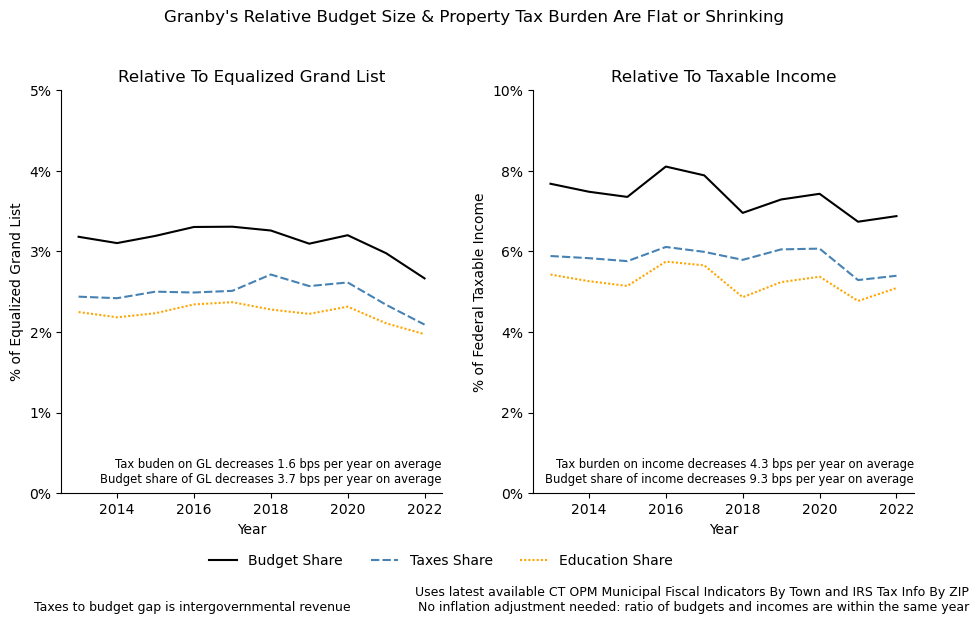

In [9]:
granby_buds = pd.melt(town_total_income.query('Town == "Granby"'), id_vars ='Year',
                        value_vars=['Budget Share Of Income', 'Budget Share Of Eq Grand List',
                                    'Taxes Share Of Income', 'Taxes Share Of Eq Grand List',
                                    'Education Share Of Income', 'Education Share Of Eq Grand List'],
                        var_name='Measure', value_name='Share')

# univariate regressions
# share of income
X = granby_buds[granby_buds['Measure'] == 'Taxes Share Of Income']
x = X['Year'].values
y = X['Share'].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)
bps = np.round(slope*10000, 1)
direction = 'increases' if bps > 0 else 'decreases'
bps = abs(bps)

X = granby_buds[granby_buds['Measure'] == 'Budget Share Of Income']
x = X['Year'].values
y = X['Share'].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)
bps2 = np.round(slope*10000, 1)
direction2 = 'increases' if bps2 > 0 else 'decreases'
bps2 = abs(bps2)

# share of grand list
X = granby_buds[granby_buds['Measure'] == 'Taxes Share Of Eq Grand List']
x = X['Year'].values
y = X['Share'].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)
bps3 = np.round(slope*10000, 1)
direction3 = 'increases' if bps3 > 0 else 'decreases'
bps3 = abs(bps3)

X = granby_buds[granby_buds['Measure'] == 'Budget Share Of Eq Grand List']
x = X['Year'].values
y = X['Share'].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)
bps4 = np.round(slope*10000, 1)
direction4 = 'increases' if bps4 > 0 else 'decreases'
bps4 = abs(bps4)


# plots
fig, axs = plt.subplots(1, 2, figsize=(11, 6.2), gridspec_kw={'wspace':.24} )

fig.suptitle("Granby's Relative Budget Size & Property Tax Burden Are Flat or Shrinking")

# relative to grand list
sns.lineplot(granby_buds.query('Measure.str.endswith("List")'),
             x='Year', y='Share', hue='Measure', style='Measure',
             palette=['black', 'steelblue', 'orange'],
             ax = axs[0], legend=None)
axs[0].set_title("Relative To Equalized Grand List")
axs[0].set_ylabel("% of Equalized Grand List")
axs[0].set_ylim(0,.05)
_l, _h = axs[0].get_xlim()
axs[0].text(_h, 0.001, f"Tax buden on GL {direction3} {bps3} bps per year on average\n" +
            f"Budget share of GL {direction4} {bps4} bps per year on average", 
            fontsize='small', ha='right', va='bottom')

# relative to income
sns.lineplot(granby_buds.query('Measure.str.endswith("Income")'), x='Year', y='Share',
             hue='Measure', style='Measure',
             palette=['black', 'steelblue', 'orange'],
             ax = axs[1])
axs[1].set_title("Relative To Taxable Income")
axs[1].set_ylabel("% of Federal Taxable Income")
axs[1].set_ylim(0,.1)
_l, _h = axs[1].get_xlim()
axs[1].text(_h, 0.002, f"Tax burden on income {direction} {bps} bps per year on average\n" + 
                       f"Budget share of income {direction2} {bps2} bps per year on average", 
            fontsize='small', ha='right', va='bottom')

# modify legend
h, lab = axs[1].get_legend_handles_labels()
axs[1].legend(h, [" ".join(l.split()[0:2]) for l in lab])

for ax in axs:
    ax.yaxis.set_major_formatter(perci_formatter)

sns.move_legend(axs[1], "upper right", bbox_to_anchor=(0.4, -0.12), ncols=3, frameon=False)
sns.despine()

plt.tight_layout()
plt.subplots_adjust(top=.85, bottom=0.2)

line1 = "Uses latest available CT OPM Municipal Fiscal Indicators By Town and IRS Tax Info By ZIP\n"
line2 = "No inflation adjustment needed: ratio of budgets and incomes are within the same year"
fig.text(.95, .01, line1 + line2, fontsize=9, ha='right')
fig.text(0.1, .01, "Taxes to budget gap is intergovernmental revenue", fontsize=9, ha='left')

plt.savefig(f"./charts/budget/{PEERVAR}/budget_share_shrinking.png", dpi=200, metadata=png_metadata)

plt.show()

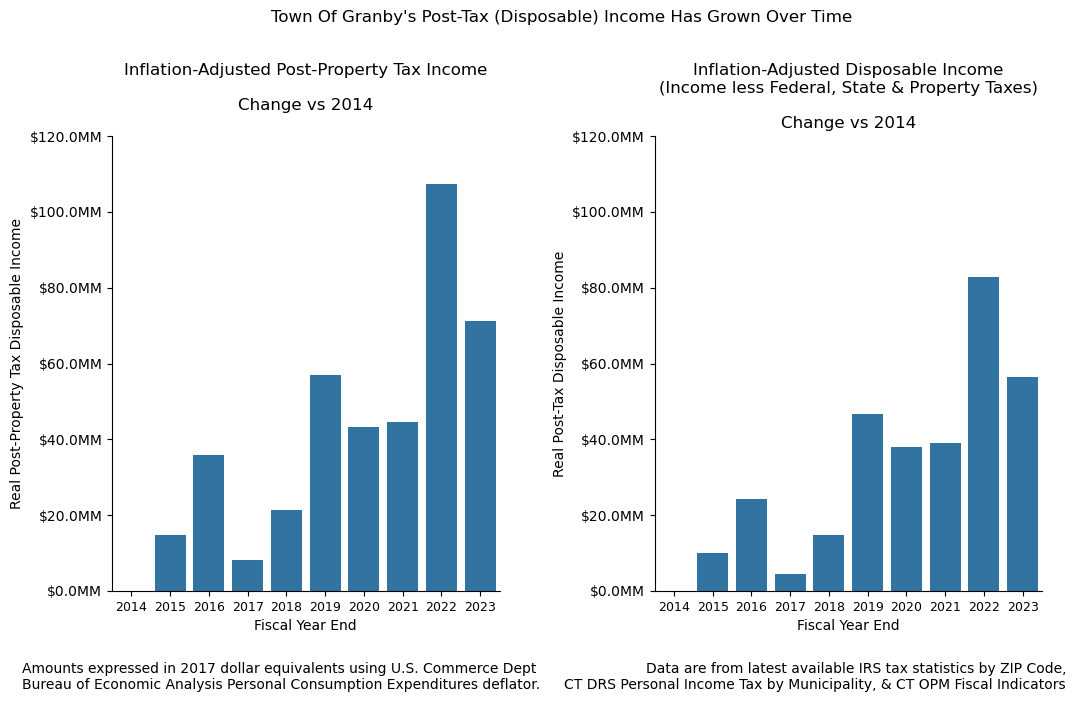

In [10]:
tmpdf = town_total_income.query('Town == "Granby"').copy()
tmpdf['Real Post-Property Tax Disposable Income'] = (tmpdf['Real Post-Local Tax Disposable Income'] - 
                                                  tmpdf['Real Post-Local Tax Disposable Income'].min())

tmpdf['Real Post-Tax Disposable Income'] = (tmpdf['Real Post-Tax Disposable Income'] - 
                                                  tmpdf['Real Post-Tax Disposable Income'].min())


fig, axs = plt.subplots(1, 2, figsize=(12,7), gridspec_kw={'wspace':.4})

fig.suptitle("Town Of Granby's Post-Tax (Disposable) Income Has Grown Over Time")

ax = axs[0]
ax = sns.barplot(data=tmpdf,
                 y='Real Post-Property Tax Disposable Income',
                 x='Fiscal Year End', ax=ax)
sns.despine()
ax.set_ylim(0,120000000)
ax.set_title('Inflation-Adjusted Post-Property Tax Income\n\nChange vs 2014\n', x=.5)
ax.yaxis.set_major_formatter(dollar_realmm_formatter)
for tick in ax.get_xticklabels():
    tick.set_fontsize(9)

ax = axs[1]
ax = sns.barplot(data=tmpdf,
                 y='Real Post-Tax Disposable Income',
                 x='Fiscal Year End',
               ax = ax)

ax.set_ylim(0,120000000)
ax.set_title('Inflation-Adjusted Disposable Income\n(Income less Federal, State & Property Taxes)\n\nChange vs 2014')
ax.yaxis.set_major_formatter(dollar_realmm_formatter)
for tick in ax.get_xticklabels():
    tick.set_fontsize(9)

#plt.tight_layout()
plt.subplots_adjust(top=.8, bottom=0.15)

line1 = "Amounts expressed in 2017 dollar equivalents using U.S. Commerce Dept\n"
line2 = "Bureau of Economic Analysis Personal Consumption Expenditures deflator."
fig.text(.05, .01, line1 + line2, ha='left')
line2 = "Data are from latest available IRS tax statistics by ZIP Code,\n"
line3 = "CT DRS Personal Income Tax by Municipality, & CT OPM Fiscal Indicators"
fig.text(.92, .01, line2 + line3, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/increasing_disposable_income.png", dpi=200, metadata=png_metadata)

plt.show()

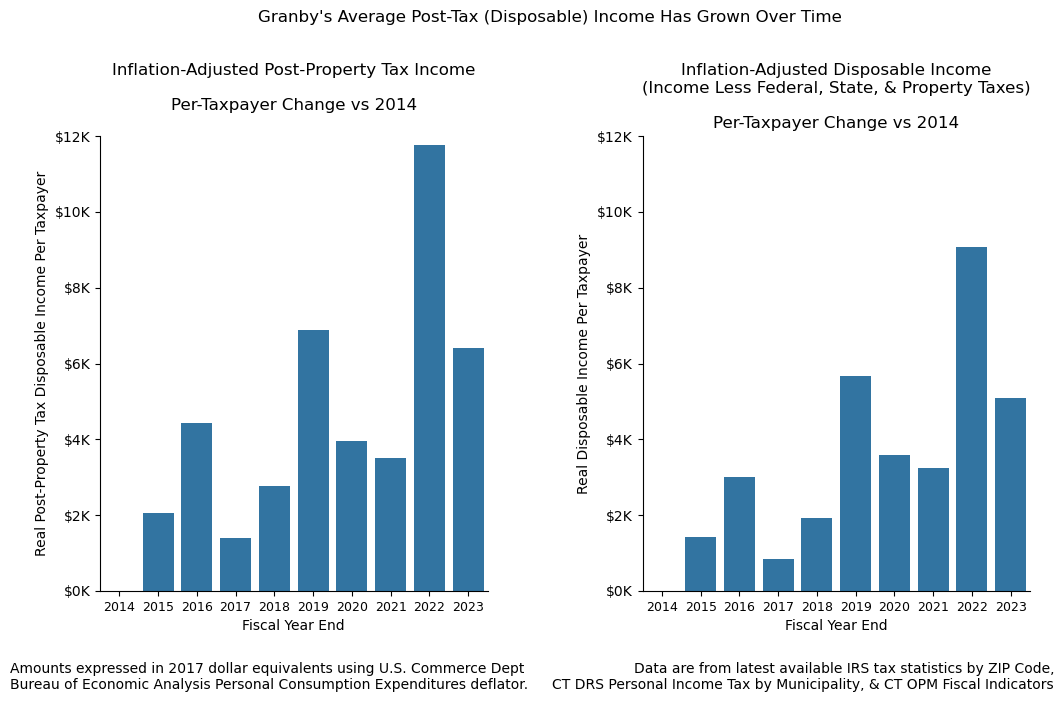

In [11]:
# per-taxpayer 
tmpdf = town_total_income.query('Town == "Granby"').copy()

tmpdf['Real Post-Property Tax Disposable Income Per Taxpayer'] = (tmpdf['Real Post-Local Tax Disposable Income Per Taxpayer'] - 
                                                  tmpdf['Real Post-Local Tax Disposable Income Per Taxpayer'].min())

tmpdf['Real Disposable Income Per Taxpayer'] = (tmpdf['Real Disposable Income Per Taxpayer'] - 
                                                  tmpdf['Real Disposable Income Per Taxpayer'].min())


fig, axs = plt.subplots(1, 2, figsize=(12,7), gridspec_kw={'wspace':.4})

fig.suptitle("Granby's Average Post-Tax (Disposable) Income Has Grown Over Time")

ax = axs[0]
ax = sns.barplot(data=tmpdf,
                 y='Real Post-Property Tax Disposable Income Per Taxpayer',
                 x='Fiscal Year End', ax=ax)
sns.despine()
ax.set_ylim(0,12000)
ax.set_title('Inflation-Adjusted Post-Property Tax Income\n\nPer-Taxpayer Change vs 2014\n', x=.5)
ax.yaxis.set_major_formatter(dollar_k_formatter)
for tick in ax.get_xticklabels():
    tick.set_fontsize(9)

ax = axs[1]
ax = sns.barplot(data=tmpdf,
                 y='Real Disposable Income Per Taxpayer',
                 x='Fiscal Year End',
               ax = ax)

ax.set_ylim(0,12000)
ax.set_title('Inflation-Adjusted Disposable Income\n(Income Less Federal, State, & Property Taxes)\n\nPer-Taxpayer Change vs 2014')
ax.yaxis.set_major_formatter(dollar_k_formatter)
for tick in ax.get_xticklabels():
    tick.set_fontsize(9)


plt.subplots_adjust(top=.8, bottom=0.15)

line1 = "Amounts expressed in 2017 dollar equivalents using U.S. Commerce Dept\n"
line2 = "Bureau of Economic Analysis Personal Consumption Expenditures deflator."
fig.text(.05, .01, line1 + line2, ha='left')
line2 = "Data are from latest available IRS tax statistics by ZIP Code,\n"
line3 = "CT DRS Personal Income Tax by Municipality, & CT OPM Fiscal Indicators"
fig.text(.92, .01, line2 + line3, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/increasing_ave_disposable_income.png", dpi=200, metadata=png_metadata)

plt.show()

### School District Comparisons

#### First in general

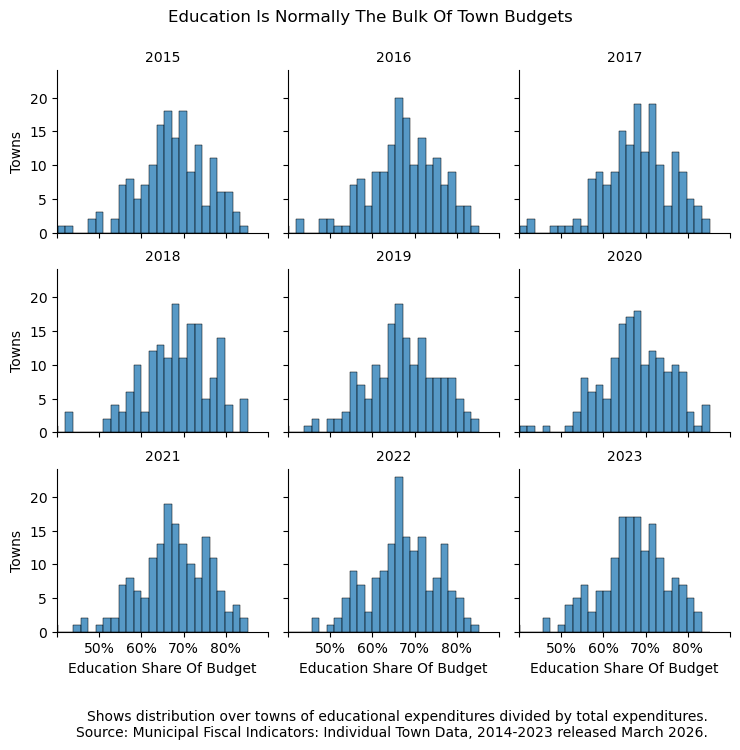

In [12]:
g = sns.displot(data=town_total_income[town_total_income['Fiscal Year End'] >= 2015],
                x='Education Share Of Budget',
                col='Fiscal Year End', col_wrap=3, height=2.5 )

g.fig.suptitle("Education Is Normally The Bulk Of Town Budgets")

g.set_titles(col_template="{col_name}")

for ax in g.axes.flat:
    ax.set_ylabel('Towns')
    ax.set_xlim(0.4,.9)
    ax.xaxis.set_major_formatter(perci_formatter)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)

plt.subplots_adjust(top=.9, bottom=0.15)

line1 = "Shows distribution over towns of educational expenditures divided by total expenditures.\n"
line2 = "Source: Municipal Fiscal Indicators: Individual Town Data, 2014-2023 released March 2026."
g.fig.text(.95,.01, line1+line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/education_share_of_budget.png", dpi=200, metadata=png_metadata)

plt.show()

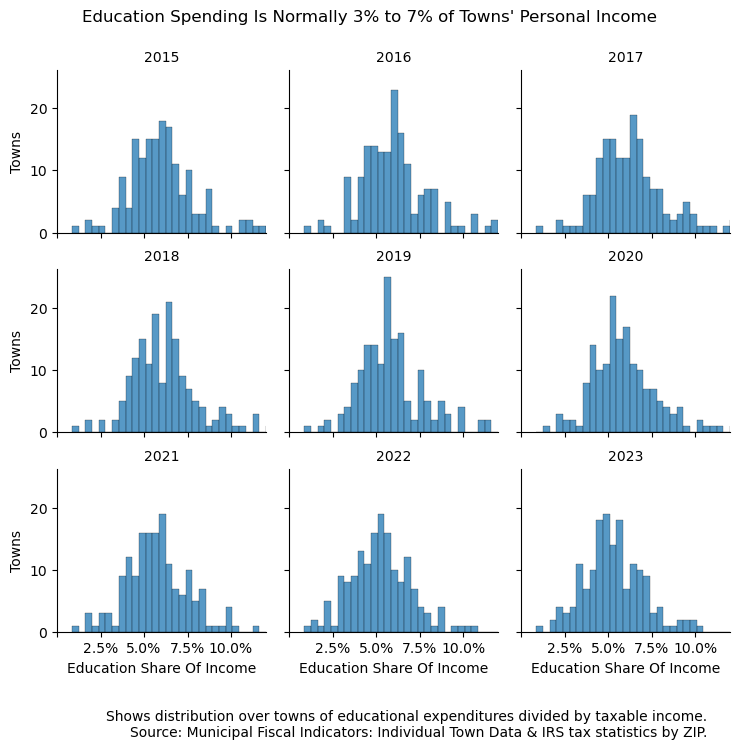

In [13]:
g = sns.displot(data=town_total_income[town_total_income['Fiscal Year End'] >= 2015], x='Education Share Of Income',
            col='Fiscal Year End', col_wrap=3, height=2.5)

g.fig.suptitle("Education Spending Is Normally 3% to 7% of Towns' Personal Income")

g.set_titles(col_template="{col_name}")

for ax in g.axes.flat:
    ax.set_ylabel('Towns')
    ax.set_xlim(0,0.12)
    ax.xaxis.set_major_formatter(perc_formatter)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)

plt.subplots_adjust(top=.9, bottom=0.15)

line1 = "Shows distribution over towns of educational expenditures divided by taxable income.\n"
line2 = "Source: Municipal Fiscal Indicators: Individual Town Data & IRS tax statistics by ZIP."
g.fig.text(.95, .01, line1+line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/education_share_of_income.png", dpi=200, metadata=png_metadata)

plt.show()

### Select peer group
From district-level data

In [14]:
# get data
district_total_income = make_ratios(district_incomes)

district_band_income = district_total_income[district_total_income['Size of adjusted gross income'] != 'Total'].copy()
district_total_income = district_total_income[district_total_income['Size of adjusted gross income'] == 'Total'].copy()

# limit to peers
district_total_income = district_total_income[(district_total_income[PEERVAR] > 0)]
district_total_income = district_total_income[district_total_income['Fiscal Year End'] > 2014]
#district_total_income = district_total_income[district_total_income['Fiscal Year End']

# for plotting
district_total_income['Granby'] = (district_total_income[PEERVAR] == 2).astype('int')
district_total_income[PEERVAR] = district_total_income[PEERVAR]\
                                .where(~district_total_income['District'].str.startswith('Region'), 3)

district_total_income.sort_values(by=['Year', PEERVAR, 'Granby'], inplace=True)

In [15]:
# show districts in peer group
print(f"Using peer variable: {PEERVAR}\n")
for d in sorted(district_total_income[district_total_income[PEERVAR] > 0].District.unique()):
    print(d)

Using peer variable: finprojB

Avon School District
Brookfield School District
Canton School District
Cheshire School District
Fairfield School District
Farmington School District
Glastonbury School District
Granby School District
Greenwich School District
Guilford School District
Monroe School District
Oxford School District
Regional School District 15
Rocky Hill School District
Simsbury School District
South Windsor School District
Trumbull School District
West Hartford School District


In [16]:
_df = district_total_income[district_total_income['Fiscal Year End'] == 2022]\
    [['District', 'Total income Amount', 'Real Income Per Taxpayer', 'Equalized Net Grand List MM',
      '% Age 65+', '% HH w/Children', 'Enrollment Rate', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']]\
    .rename(columns={'Equalized Net Grand List MM': 'EQ Grand List'}).copy().sort_values('Real Income Per Taxpayer')

_df['District Income'] = _df["Total income Amount"]/1000
_df['EQ Grand List'] = _df['EQ Grand List']/1000
_df[['District', 'District Income', 'EQ Grand List', 'Real Income Per Taxpayer', '% Age 65+', 'Enrollment Rate', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']]\
    .style.format({"District Income": "${:,.0f} B", "EQ Grand List": "${:,.2f} B", "Real Income Per Taxpayer": "${:,.0f}"} |
                  {'Enrollment Rate': "{:.1%}"} |
                  {x: "{:.0f}%" for x in ['% Age 65+', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']})\
    .hide(axis="index")

District,District Income,EQ Grand List,Real Income Per Taxpayer,% Age 65+,Enrollment Rate,% Owner Occ,% SNAP,% w/Bachelors+,% Management
Rocky Hill School District,"$1,083 B",$3.77 B,"$66,003",36%,12.9%,66%,5%,48%,52%
Oxford School District,$798 B,$2.41 B,"$71,081",36%,13.6%,92%,3%,46%,51%
South Windsor School District,"$1,573 B",$5.13 B,"$72,143",33%,18.3%,84%,4%,56%,60%
Monroe School District,"$1,185 B",$3.68 B,"$76,103",33%,18.0%,93%,2%,55%,59%
Trumbull School District,"$2,410 B",$8.29 B,"$81,527",34%,18.2%,89%,3%,60%,58%
Canton School District,$660 B,$1.74 B,"$82,203",38%,15.0%,83%,3%,57%,54%
Brookfield School District,"$1,191 B",$3.96 B,"$82,380",38%,15.1%,85%,2%,51%,49%
Granby School District,$780 B,$1.76 B,"$82,967",34%,15.6%,91%,3%,56%,53%
Cheshire School District,"$1,872 B",$5.06 B,"$83,358",35%,14.3%,88%,3%,62%,64%
Regional School District 15,"$2,151 B",$5.58 B,"$93,921",49%,12.9%,87%,6%,53%,57%


### Exclude Greenwich

In [17]:
district_total_income = district_total_income[~district_total_income['District'].str.startswith('Greenwich')]

In [18]:
# color scheme
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in district_total_income['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

peer_cols = {3: (0.19, 0.27, 0.57, .4),
             2: 'black',
             1: (0.529, 0.808, 0.922, .4)}

flag_cols = {0:(0.69, 0.77, 0.87, .4), 1:'black'}

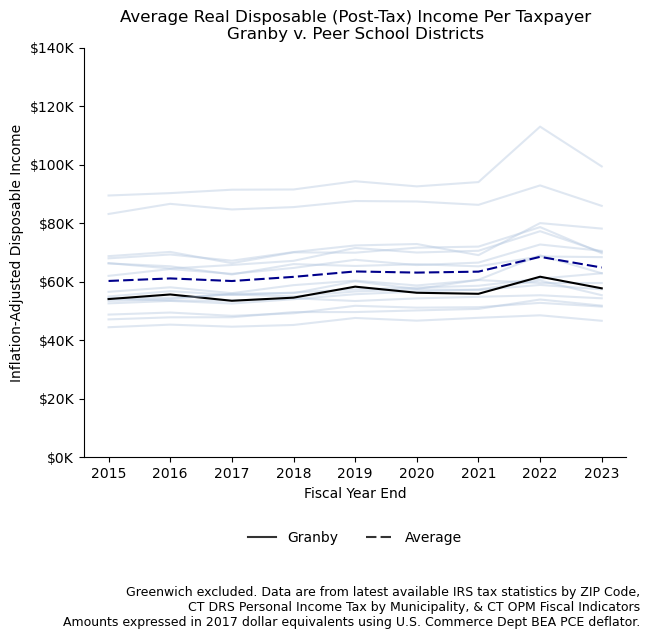

In [19]:
_ave = pd.DataFrame(district_total_income.groupby('Fiscal Year End')['Real Disposable Income Per Taxpayer'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'

tmpdf = pd.concat([district_total_income, _ave], axis=0, ignore_index=True)
tmpdf['Granby'] = 'Other'
tmpdf['Granby'] = tmpdf['Granby'].where(~tmpdf['District'].str.startswith('Granby'), 'Granby')
tmpdf['Granby'] = tmpdf['Granby'].where(~tmpdf['District'].str.startswith('Average'), 'Average')


fig, g = plt.subplots(1, 1, figsize=(7,6.5))
sns.lineplot(data=tmpdf,
                y='Real Disposable Income Per Taxpayer', 
                x='Fiscal Year End', hue='District',
                style='Granby', dashes=[(None, None), (None, None), (5, 2)],
                 ax=g,
                palette=school_cols)
sns.despine()
g.set_title('Average Real Disposable (Post-Tax) Income Per Taxpayer\nGranby v. Peer School Districts')
g.set_ylabel('Inflation-Adjusted Disposable Income')
g.yaxis.set_major_formatter(dollar_k_formatter)
g.set_ylim(0, 140000)
g.legend()

h, lab = g.get_legend_handles_labels()
g.legend(h[-2:], lab[-2:])
sns.move_legend(g, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncols=2, frameon=False)


plt.subplots_adjust(top=.9, bottom=0.27)

line3 = "Amounts expressed in 2017 dollar equivalents using U.S. Commerce Dept BEA PCE deflator."
line1 = "Greenwich excluded. Data are from latest available IRS tax statistics by ZIP Code,\n"
line2 = "CT DRS Personal Income Tax by Municipality, & CT OPM Fiscal Indicators\n"
fig.text(.92, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/peer_real_disposable_income.png", dpi=200, metadata=png_metadata)

plt.show()

### Relative to incomes

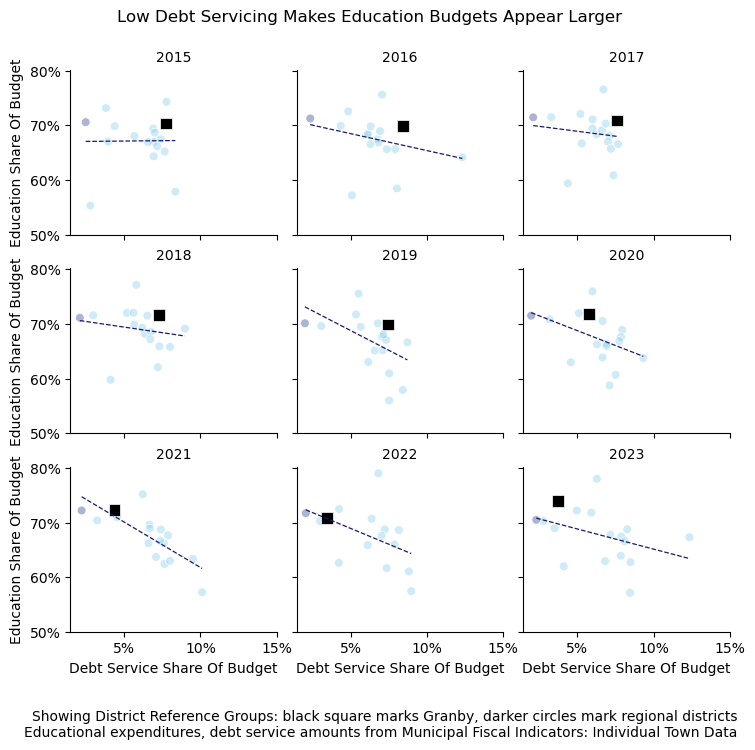

In [20]:
g = sns.relplot(data=district_total_income[(district_total_income['Debt Service Share Of Budget'] <= .15)
                                        & (district_total_income['Education Share Of Budget'] >= .5)],
                col='Fiscal Year End', col_wrap=3,
                x='Debt Service Share Of Budget', y='Education Share Of Budget',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Debt Service Share Of Budget', y='Education Share Of Budget', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.set_ylim(bottom=.5)
    ax.set_xlim(right=.15)
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(perci_formatter)
    #plt.xscale('log') 

g.fig.suptitle("Low Debt Servicing Makes Education Budgets Appear Larger")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Educational expenditures, debt service amounts from Municipal Fiscal Indicators: Individual Town Data"
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/education_relative_to_debt.png", dpi=200, metadata=png_metadata)

plt.show()

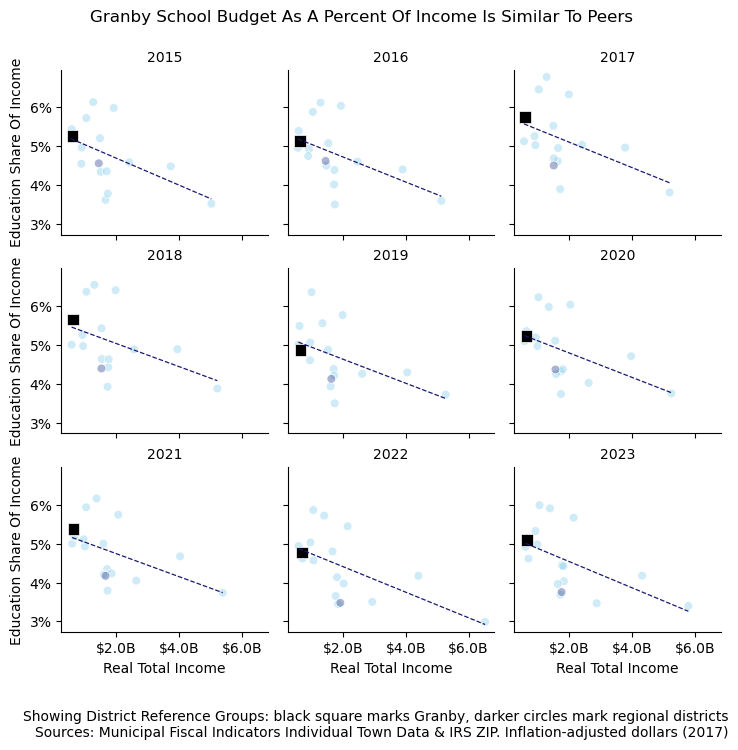

In [21]:
g = sns.relplot(data=district_total_income,
                col='Fiscal Year End', col_wrap=3,
                x='Real Total Income', y='Education Share Of Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Real Total Income', y='Education Share Of Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_realbb_formatter)
    #plt.xscale('log') 

g.fig.suptitle("Granby School Budget As A Percent Of Income Is Similar To Peers")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Inflation-adjusted dollars (2017)"
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/ed_income_share_v_total_income.png", dpi=200, metadata=png_metadata)

plt.show()

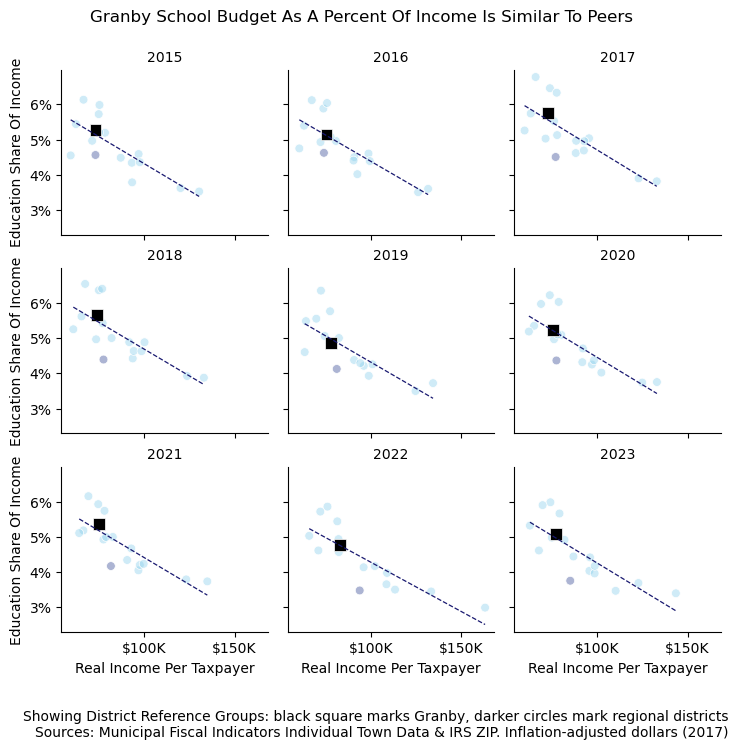

In [22]:
g = sns.relplot(data=district_total_income,
                col='Fiscal Year End', col_wrap=3,
                x='Real Income Per Taxpayer', y='Education Share Of Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Real Income Per Taxpayer', y='Education Share Of Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_k_formatter)
    #plt.xscale('log') 

g.fig.suptitle("Granby School Budget As A Percent Of Income Is Similar To Peers")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Inflation-adjusted dollars (2017)"
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/ed_income_share_v_ave_income.png", dpi=200, metadata=png_metadata)

plt.show()

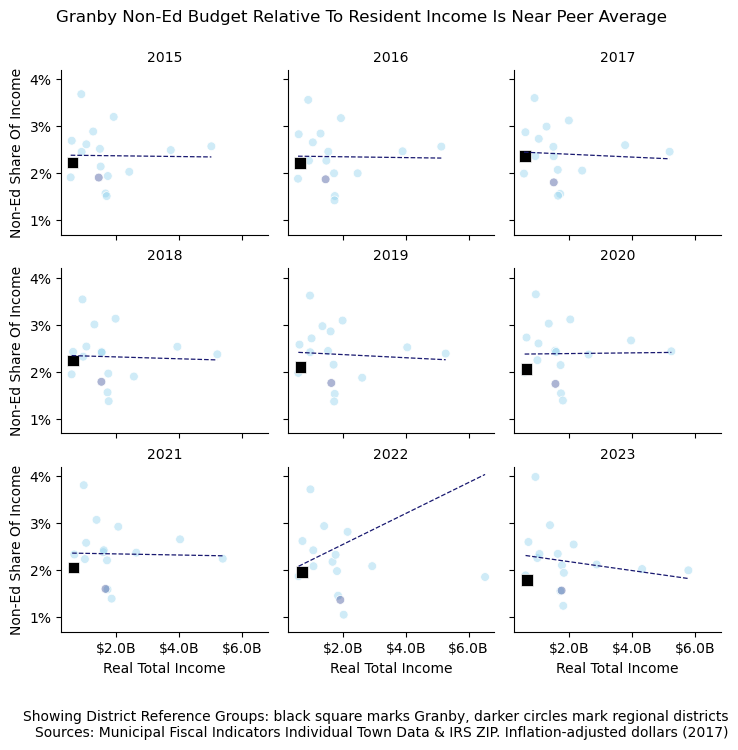

In [23]:
g = sns.relplot(data=district_total_income.rename(columns={'Non-Education Share Of Income': 'Non-Ed Share Of Income'}),
                col='Fiscal Year End', col_wrap=3,
                x='Real Total Income', y='Non-Ed Share Of Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Real Total Income', y='Non-Ed Share Of Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.set_ylim(top=.042)
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_realbb_formatter)
    #plt.xscale('log') 

g.fig.suptitle("Granby Non-Ed Budget Relative To Resident Income Is Near Peer Average")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Inflation-adjusted dollars (2017)"
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/noned_income_share_v_total_income.png", dpi=200, metadata=png_metadata)

plt.show()

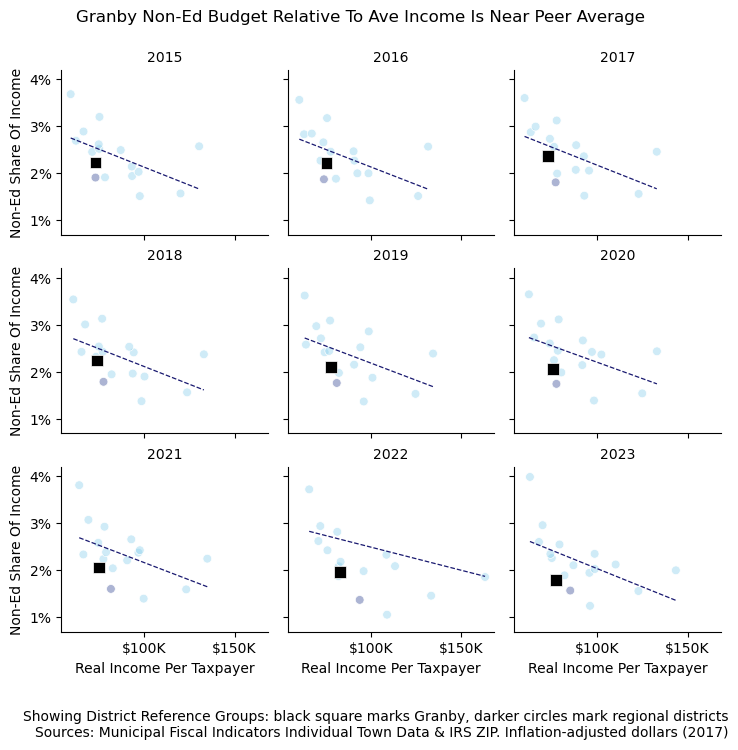

In [24]:
g = sns.relplot(data=district_total_income.rename(columns={'Non-Education Share Of Income': 'Non-Ed Share Of Income'}),
                col='Fiscal Year End', col_wrap=3,
                x='Real Income Per Taxpayer', y='Non-Ed Share Of Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Real Income Per Taxpayer', y='Non-Ed Share Of Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.set_ylim(top=.042)
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_k_formatter)
    #plt.xscale('log') 

g.fig.suptitle("Granby Non-Ed Budget Relative To Ave Income Is Near Peer Average")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Inflation-adjusted dollars (2017)"
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/noned_income_share_v_ave_income.png", dpi=200, metadata=png_metadata)
plt.show()

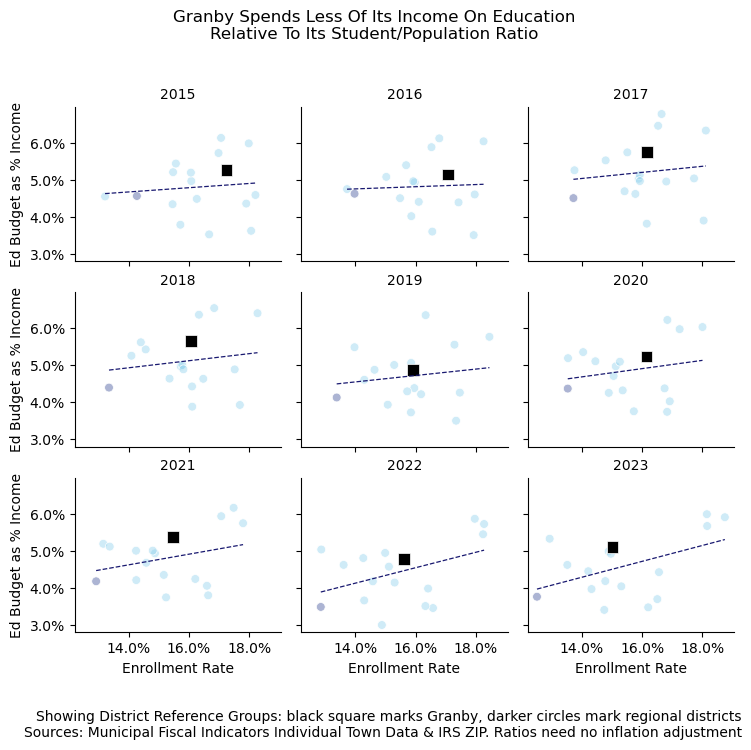

In [25]:
g = sns.relplot(data=district_total_income.rename(columns={'Education Share Of Income': 'Ed Budget as % Income'}),
                col='Fiscal Year End', col_wrap=3,
                x='Enrollment Rate', y='Ed Budget as % Income', 
                height=2.5,  legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")

g.map_dataframe(sns.regplot, x='Enrollment Rate', y='Ed Budget as % Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(perc_formatter)
    ax.yaxis.set_major_formatter(perc_formatter)

g.fig.suptitle("Granby Spends Less Of Its Income On Education\nRelative To Its Student/Population Ratio")

plt.subplots_adjust(top=.85, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Ratios need no inflation adjustment"
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/ed_income_share_v_studentperc.png", dpi=200, metadata=png_metadata)
plt.show()

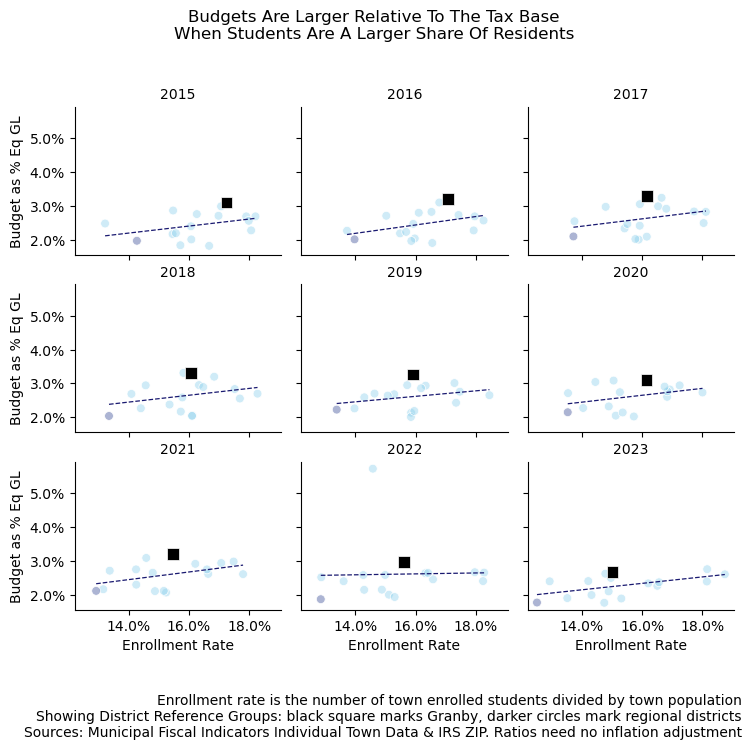

In [26]:
g = sns.relplot(data=district_total_income.rename(columns={'Budget Share Of Eq Grand List': 'Budget as % Eq GL'}),
                col='Fiscal Year End', col_wrap=3,
                x='Enrollment Rate', y='Budget as % Eq GL', 
                height=2.5,  legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")

g.map_dataframe(sns.regplot, x='Enrollment Rate', y='Budget as % Eq GL', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(perc_formatter)
    ax.yaxis.set_major_formatter(perc_formatter)

g.fig.suptitle("Budgets Are Larger Relative To The Tax Base\nWhen Students Are A Larger Share Of Residents")

plt.subplots_adjust(top=.85, bottom=0.18)
line1 = "Enrollment rate is the number of town enrolled students divided by town population\n"
line2 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line3 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Ratios need no inflation adjustment"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/budget_gl_share_v_studentperc.png", dpi=200, metadata=png_metadata)

plt.show()

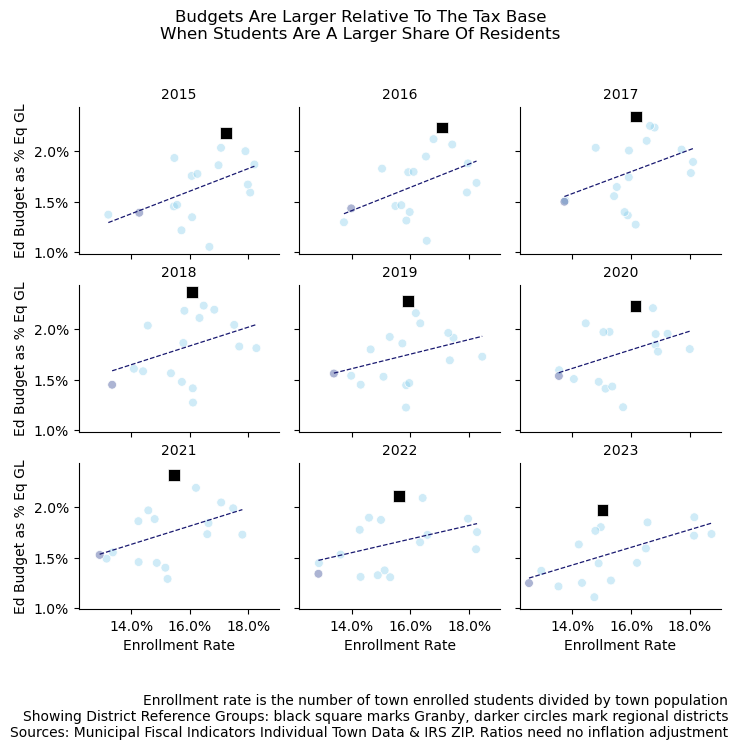

In [27]:
g = sns.relplot(data=district_total_income.rename(columns={'Education Share Of Eq Grand List': 'Ed Budget as % Eq GL'}),
                col='Fiscal Year End', col_wrap=3,
                x='Enrollment Rate', y='Ed Budget as % Eq GL', 
                height=2.5,  legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")

g.map_dataframe(sns.regplot, x='Enrollment Rate', y='Ed Budget as % Eq GL', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(perc_formatter)
    ax.yaxis.set_major_formatter(perc_formatter)

g.fig.suptitle("Budgets Are Larger Relative To The Tax Base\nWhen Students Are A Larger Share Of Residents")

plt.subplots_adjust(top=.85, bottom=0.18)
line1 = "Enrollment rate is the number of town enrolled students divided by town population\n"
line2 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line3 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Ratios need no inflation adjustment"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/edbudget_gl_share_v_studentperc.png", dpi=200, metadata=png_metadata)

plt.show()

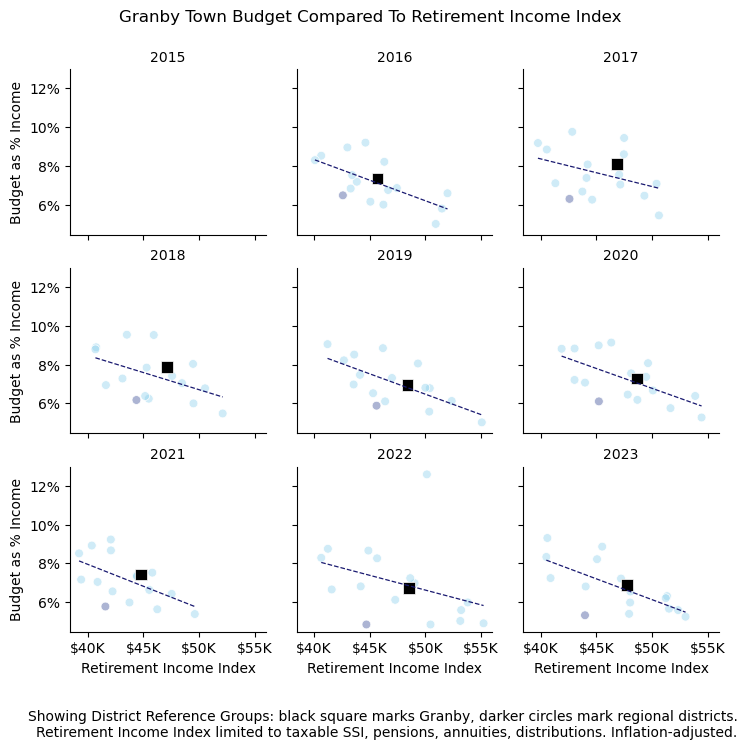

In [28]:
g = sns.relplot(data=district_total_income.rename(columns={'Budget Share Of Income': 'Budget as % Income'}),
                col='Fiscal Year End', col_wrap=3,
                x='Retirement Income Index', y='Budget as % Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Retirement Income Index', y='Budget as % Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_k_formatter)
    #plt.xscale('log') 

g.fig.suptitle("Granby Town Budget Compared To Retirement Income Index")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts.\n"
line2 = "Retirement Income Index limited to taxable SSI, pensions, annuities, distributions. Inflation-adjusted."
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/budget_income_share_v_retirementindex.png", dpi=200, metadata=png_metadata)

plt.show()

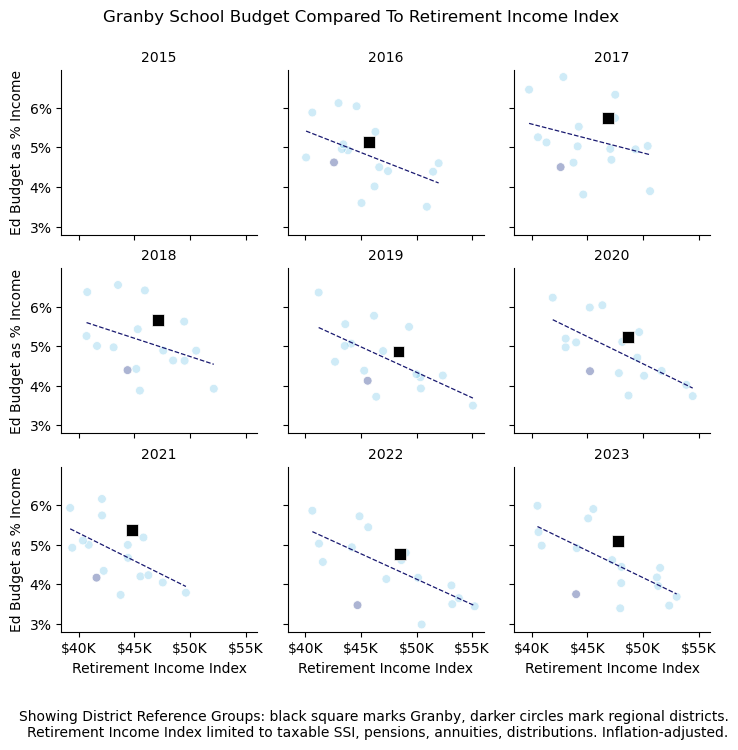

In [29]:
g = sns.relplot(data=district_total_income.rename(columns={'Education Share Of Income': 'Ed Budget as % Income'}),
                col='Fiscal Year End', col_wrap=3,
                x='Retirement Income Index', y='Ed Budget as % Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Retirement Income Index', y='Ed Budget as % Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_k_formatter)
    #plt.xscale('log') 

g.fig.suptitle("Granby School Budget Compared To Retirement Income Index")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts.\n"
line2 = "Retirement Income Index limited to taxable SSI, pensions, annuities, distributions. Inflation-adjusted."
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/edbudget_income_share_v_retirementindex.png", dpi=200, metadata=png_metadata)

plt.show()

### Relative to Grand List
#### Less Important

Taxes are paid out of incomes, not home values. The equalized grand list is useful as a measure of wealth but is messy because tax bases differ by locality.

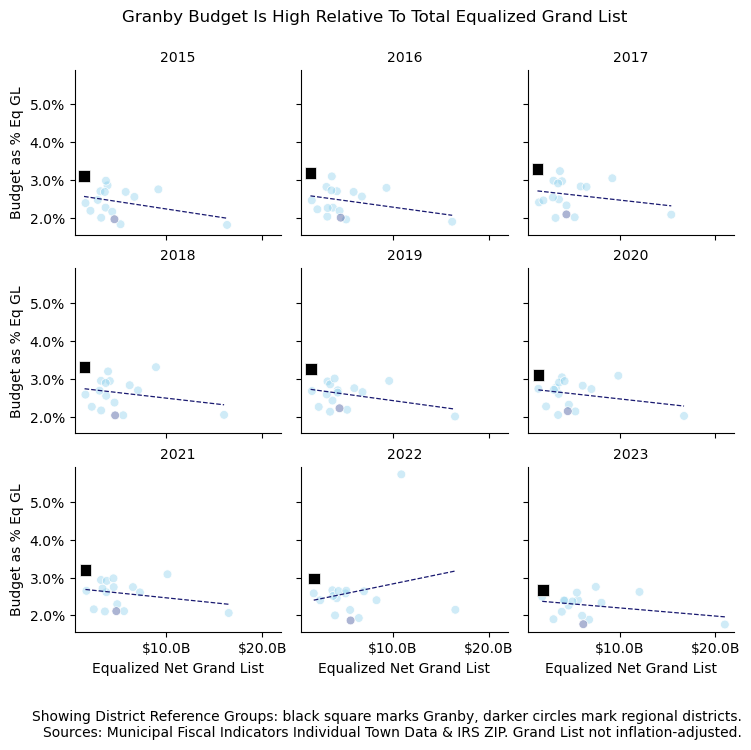

In [30]:
g = sns.relplot(data=district_total_income[district_total_income['Fiscal Year End'] > 2014]\
                     .rename(columns={'Budget Share Of Eq Grand List': 'Budget as % Eq GL'}),
                col='Fiscal Year End', col_wrap=3,
                x='Equalized Net Grand List', y='Budget as % Eq GL', 
                height=2.5,  legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")

g.map_dataframe(sns.regplot, x='Equalized Net Grand List', y='Budget as % Eq GL', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(dollar_realbb_formatter)
    ax.yaxis.set_major_formatter(perc_formatter)

g.fig.suptitle("Granby Budget Is High Relative To Total Equalized Grand List")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts.\n"
line2 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Grand List not inflation-adjusted."
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/budget_gl_share_v_gl.png", dpi=200, metadata=png_metadata)

plt.show()

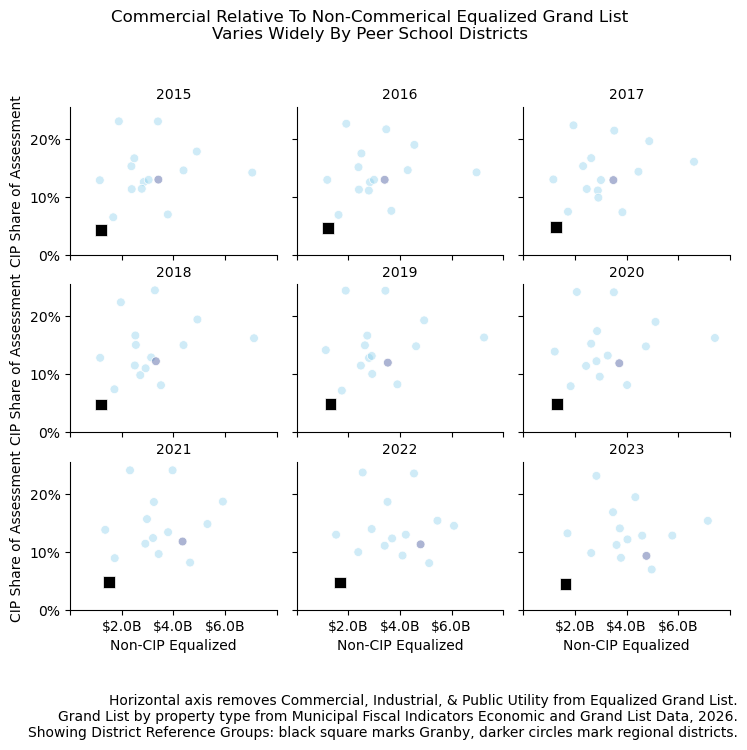

In [31]:
g = sns.relplot(data=district_total_income,
                col='Fiscal Year End', col_wrap=3,
                x='Non-CIP Equalized', y='CIP Share of Assessment',
                height=2.5, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)
g.set_titles(col_template="{col_name}")

for ax in g.axes.flat:
    ax.set_ylim(bottom=0)
    ax.set_xlim(0, 8000000000)
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_realbb_formatter)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)

g.fig.suptitle("Commercial Relative To Non-Commerical Equalized Grand List\nVaries Widely By Peer School Districts")

plt.subplots_adjust(top=.85, bottom=0.18)

line3 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts."
line1 = "Horizontal axis removes Commercial, Industrial, & Public Utility from Equalized Grand List.\n"
line2 = "Grand List by property type from Municipal Fiscal Indicators Economic and Grand List Data, 2026.\n"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/cip_gl_share_v_noncip_gl.png", dpi=200, metadata=png_metadata)

plt.show()

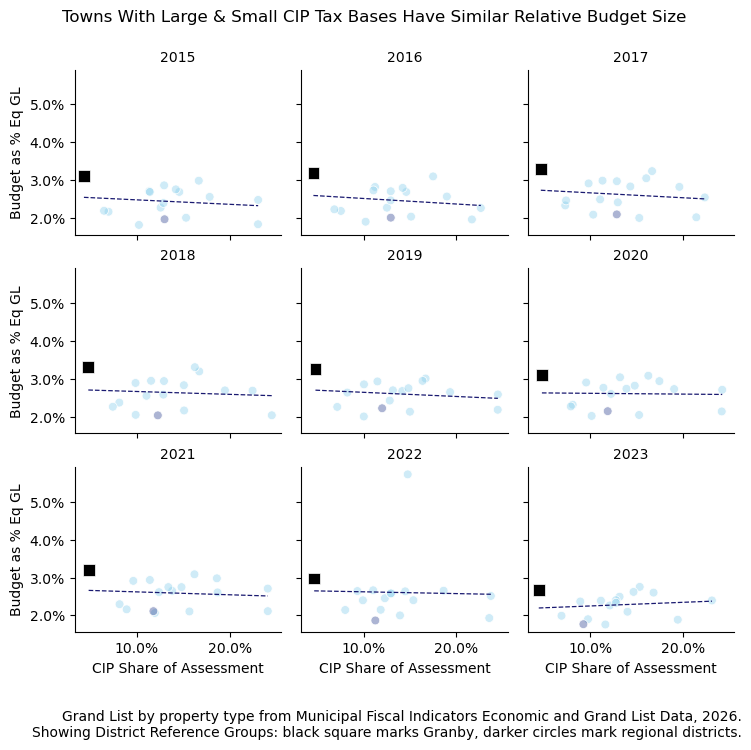

In [32]:

g = sns.relplot(data=district_total_income[district_total_income['Fiscal Year End'] > 2014]\
                     .rename(columns={'Budget Share Of Eq Grand List': 'Budget as % Eq GL'}),
                col='Fiscal Year End', col_wrap=3,
                x='CIP Share of Assessment', y='Budget as % Eq GL', 
                height=2.5,  legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")

g.map_dataframe(sns.regplot, x='CIP Share of Assessment', y='Budget as % Eq GL', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(perc_formatter)
    ax.yaxis.set_major_formatter(perc_formatter)


g.fig.suptitle("Towns With Large & Small CIP Tax Bases Have Similar Relative Budget Size")

plt.subplots_adjust(top=.9, bottom=0.15)

line1 = "Grand List by property type from Municipal Fiscal Indicators Economic and Grand List Data, 2026.\n"
line2 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts."
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/budget_gl_share_v_cip_share.png", dpi=200, metadata=png_metadata)

plt.show()

In [33]:
district_total_income[district_total_income['Education Share Of Income'] < .025]

,District,Year,Fiscal Year End,Size of adjusted gross income,Number of returns,Number of single returns,Number of joint returns,Number of head of household returns,Number of exemptions,Number of dependents,...,Real Income Per Taxpayer,Real Disposable Income Per Taxpayer,Real Post-Local Tax Disposable Income Per Taxpayer,Flat Tax Per Single Taxpayer,Real Flat Tax Per Taxpayer,Retirement Income Index,Average School Enrollment,Population,Enrollment Rate,Granby


### Are Retirees 'Getting Squeezed'?

#### Break out totals & income bands

In [34]:
granby_incomes = town_incomes[(town_incomes['Town'] == 'Granby') &\
                              (town_incomes['Size of adjusted gross income'] != 'Total')].copy()
granby_incomes['Income Band'] = granby_incomes['Income Band'].cat.remove_unused_categories()
granby_incomes['Number of Non-Elderly Returns'] = (granby_incomes['Number of returns']
                                       - granby_incomes['Number of elderly returns'].replace(0, np.nan))
granby_incomes['Elderly Share of Returns'] = granby_incomes['Number of elderly returns'] / granby_incomes['Number of returns']

#### Share of returns in each income band

In [35]:
# % of elderly in each band
ttl_elderly = granby_incomes.groupby('Year')['Number of elderly returns'].sum()
ttl_elderly.name = 'total elderly returns'
ttl_elderly = pd.DataFrame(ttl_elderly).reset_index(drop=False)
granby_incomes = granby_incomes.merge(ttl_elderly, on='Year', how='left')
granby_incomes['Share of Elderly Returns'] = granby_incomes['Number of elderly returns']/granby_incomes['total elderly returns']

In [36]:
# % of non-elderly in each band
ttl_non_elderly = granby_incomes.groupby('Year')['Number of Non-Elderly Returns'].sum()
ttl_non_elderly.name = 'total nonelderly returns'
ttl_non_elderly = pd.DataFrame(ttl_non_elderly).reset_index(drop=False)
granby_incomes = granby_incomes.merge(ttl_non_elderly, on='Year', how='left')
granby_incomes['Share of Non-Elderly Returns'] = granby_incomes['Number of Non-Elderly Returns']/granby_incomes['total nonelderly returns']

In [37]:
# % of elderly returns in each band
# each column sums to 100%
# For the last two reported years, over 46% of elderly returns were in $100K and up 
eld_dist = granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Share of Elderly Returns')
eld_dist.style.format("{:.1%}").set_caption('% of Elderly Returns In Each Band (column sums to 100%)')

Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000",17.7%,18.7%,16.2%,16.5%,15.4%,16.5%,14.5%,15.4%
"\$25,000 under \$50,000",15.2%,13.3%,13.3%,12.1%,13.8%,14.9%,11.5%,12.5%
"\$50,000 under \$75,000",14.6%,14.5%,15.6%,14.3%,12.2%,13.9%,14.5%,12.5%
"\$75,000 under \$100,000",15.2%,15.1%,13.9%,13.2%,14.4%,13.9%,12.5%,13.0%
"\$100,000 under \$200,000",27.4%,28.3%,28.9%,30.2%,30.9%,28.9%,30.5%,31.2%
"\$200,000 or more",9.8%,10.2%,12.1%,13.7%,13.3%,11.9%,16.5%,15.4%


In [38]:
# % of elderly returns in each band
# each column sums to 100%
# For the last two reported years, over 46% of elderly returns were in $100K and up 
eld_dist.sort_index(ascending=False).cumsum(axis=0).sort_index(ascending=True)\
         .style.format("{:.1%}")\
        .set_caption('Cumulative % of Elderly Returns In Or Above Each Band (column sums to 100%)')

Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000",100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%
"\$25,000 under \$50,000",82.3%,81.3%,83.8%,83.5%,84.6%,83.5%,85.5%,84.6%
"\$50,000 under \$75,000",67.1%,68.1%,70.5%,71.4%,70.7%,68.6%,74.0%,72.1%
"\$75,000 under \$100,000",52.4%,53.6%,54.9%,57.1%,58.5%,54.6%,59.5%,59.6%
"\$100,000 under \$200,000",37.2%,38.6%,41.0%,44.0%,44.1%,40.7%,47.0%,46.6%
"\$200,000 or more",9.8%,10.2%,12.1%,13.7%,13.3%,11.9%,16.5%,15.4%


#### Compare to Non-Retirees

In [39]:
# % of elderly returns in each band
# each column sums to 100%
# For the last two reported years, over 46% of elderly returns were in $100K and up 
noneld_dist = granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Share of Non-Elderly Returns')
noneld_dist.style.format("{:.1%}").set_caption('% of Non-Elderly Returns In Each Band (column sums to 100%)')

Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000",28.1%,27.0%,26.6%,25.1%,24.3%,22.5%,21.1%,21.0%
"\$25,000 under \$50,000",12.6%,13.9%,13.2%,14.0%,13.8%,13.9%,15.1%,13.7%
"\$50,000 under \$75,000",11.9%,11.0%,11.3%,11.6%,13.5%,13.9%,11.4%,11.6%
"\$75,000 under \$100,000",9.3%,9.4%,10.0%,10.2%,9.8%,9.9%,10.8%,10.2%
"\$100,000 under \$200,000",25.3%,26.2%,25.6%,24.8%,24.1%,25.1%,25.1%,25.3%
"\$200,000 or more",12.9%,12.6%,13.2%,14.3%,14.6%,14.7%,16.5%,18.1%


In [40]:
# % of elderly returns in each band
# each column sums to 100%
# For the last two reported years, over 46% of elderly returns were in $100K and up 
noneld_dist.sort_index(ascending=False).cumsum(axis=0).sort_index(ascending=True)\
    .style.format("{:.1%}")\
    .set_caption('% of Non-Elderly Returns In or Above Each Band (column sums to 100%)')

Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000",100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%
"\$25,000 under \$50,000",71.9%,73.0%,73.4%,74.9%,75.7%,77.5%,78.9%,79.0%
"\$50,000 under \$75,000",59.3%,59.2%,60.2%,60.9%,61.9%,63.6%,63.8%,65.2%
"\$75,000 under \$100,000",47.4%,48.2%,48.8%,49.3%,48.4%,49.7%,52.4%,53.6%
"\$100,000 under \$200,000",38.1%,38.7%,38.8%,39.1%,38.6%,39.8%,41.6%,43.4%
"\$200,000 or more",12.9%,12.6%,13.2%,14.3%,14.6%,14.7%,16.5%,18.1%


In [41]:
# % of returns in each band that are elderly returns
granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Elderly Share of Returns')\
              .style.format("{:.1%}")

Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000",21.0%,23.1%,21.7%,24.4%,24.0%,27.1%,27.1%,29.1%
"\$25,000 under \$50,000",33.8%,29.3%,31.5%,29.7%,33.3%,35.4%,29.1%,33.8%
"\$50,000 under \$75,000",34.3%,36.4%,38.6%,37.7%,31.1%,33.8%,40.8%,37.7%
"\$75,000 under \$100,000",41.0%,41.0%,38.7%,38.7%,42.2%,41.5%,38.5%,41.5%
"\$100,000 under \$200,000",31.5%,32.0%,34.0%,37.4%,38.9%,36.8%,39.6%,40.9%
"\$200,000 or more",24.2%,26.2%,29.6%,32.1%,31.2%,29.1%,35.1%,32.3%


#### Retirement Income Index
This is only an index useful for comparison.

Average taxable SSI, Pensions, Annuities, Retirement Acccount distributions per "Elderly" return. 

This understates retiree income. First, it excludes other sources of taxable income, non-taxable distributions or interest, or taxable dividends or interest because those are not reported separately by the IRS. Second, because the number of elderly returns used as the denominator is larger than the number of returns reporting taxable pensions, annuities, and distributions, the resulting average is likely underestimated.

In [42]:
town_total_income.query('Town == "Granby"')[['Year', 'Number of returns', 'Number of elderly returns', 'Retirement Income Index']]\
    .style.format({'Number of returns':"{:,.0f}", 'Number of elderly returns':"{:,.0f}",'Retirement Income Index':"${:,.0f}"})

,Year,Number of returns,Number of elderly returns,Retirement Income Index
4248,2013,"5,520",0,$nan
4255,2014,"5,480",0,$nan
4262,2015,"5,520","1,640","$45,700"
4269,2016,"5,480","1,660","$46,859"
4276,2017,"5,520","1,730","$47,127"
4283,2018,"5,530","1,820","$48,384"
4290,2019,"5,660","1,880","$48,665"
4297,2020,"5,760","1,940","$44,783"
4304,2021,"5,700","2,000","$48,541"
4311,2022,"5,790","2,080","$47,723"


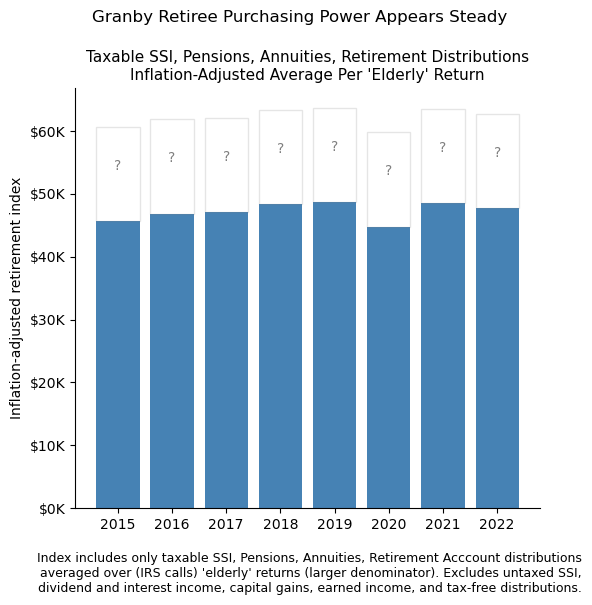

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(6,6),)
fig.suptitle("Granby Retiree Purchasing Power Appears Steady")

ax.set_title("Taxable SSI, Pensions, Annuities, Retirement Distributions\nInflation-Adjusted Average Per 'Elderly' Return",
            fontsize=11)

_df = town_total_income[town_total_income['Number of elderly returns'] > 0].query('Town == "Granby"')

bars = ax.bar(_df['Year'],
       _df['Retirement Income Index'],
       facecolor='steelblue', )

for bar in bars:
    height = bar.get_height() + 7000
    ax.annotate("?",
                xy=(bar.get_x() + bar.get_width() / 2, height), #
                xytext=(0, 3), # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', color='gray')

ax.bar(_df['Year'],
       _df.shape[0]*[15000],
       bottom=_df['Retirement Income Index'],
       edgecolor='gray', facecolor='none', alpha=.2)
sns.despine()

ax.set_ylabel("Inflation-adjusted retirement index")
ax.yaxis.set_major_formatter(dollar_k_formatter)
plt.subplots_adjust(top=.85, bottom=0.15)

line1 = "Index includes only taxable SSI, Pensions, Annuities, Retirement Acccount distributions\n"
line2 = "averaged over (IRS calls) 'elderly' returns (larger denominator). Excludes untaxed SSI,\n"
line3 = "dividend and interest income, capital gains, earned income, and tax-free distributions."
fig.text(.97, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/social_security/real_retirement_index.png", dpi=200, metadata=png_metadata)

plt.show()

### Nominal income distributions

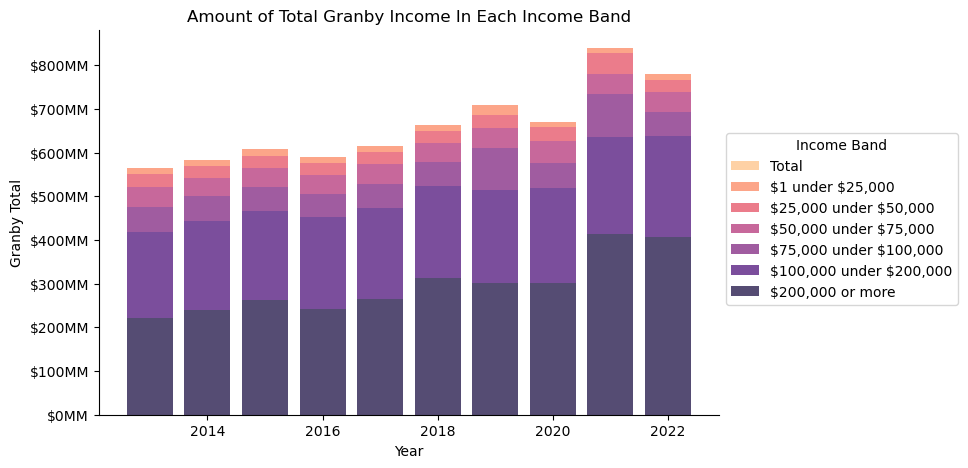

In [44]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(town_band_income[town_band_income.Town == 'Granby'],
             x="Year", weights='Total income Amount',
             palette="magma_r", discrete=True, edgecolor=None, shrink=.8,
            hue='Income Band', multiple='stack', ax=ax)

ax.yaxis.set_major_formatter(dollar_mm_formatter)

# Add labels and title
ax.set_ylabel("Granby Total")
ax.set_title("Amount of Total Granby Income In Each Income Band")

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, .75))
sns.despine()
plt.show()

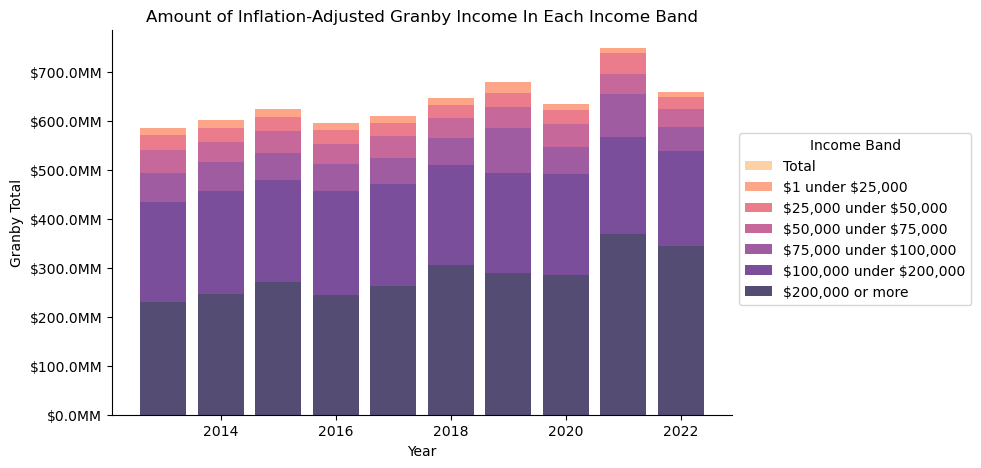

In [45]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(town_band_income[town_band_income.Town == 'Granby'],
             x="Year", weights='Real Total Income',
             palette="magma_r", discrete=True, edgecolor=None, shrink=.8,
            hue='Income Band', multiple='stack', ax=ax)

ax.yaxis.set_major_formatter(dollar_realmm_formatter)

# Add labels and title
ax.set_ylabel("Granby Total")
ax.set_title("Amount of Inflation-Adjusted Granby Income In Each Income Band")

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, .75))
sns.despine()
plt.show()

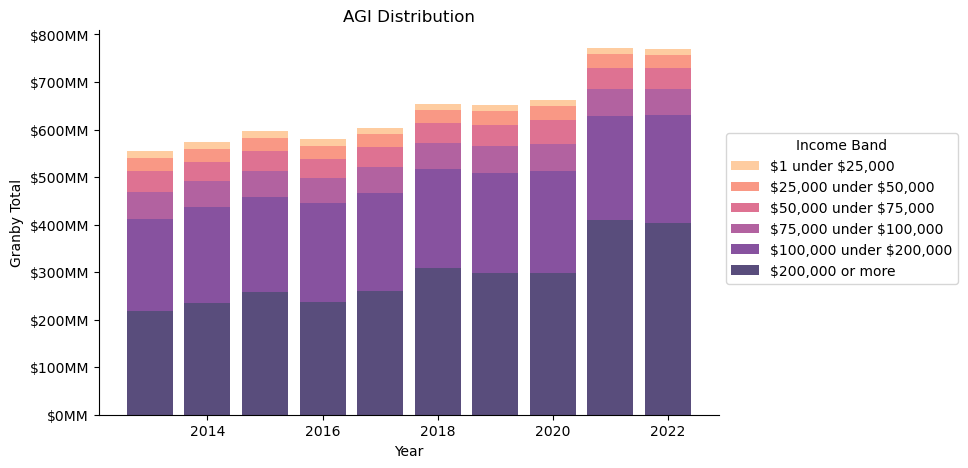

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(granby_incomes, x="Year", weights='Adjusted gross income (AGI)',
             palette="magma_r", discrete=True, edgecolor=None, shrink=.8,
            hue='Income Band', multiple='stack', ax=ax)

ax.yaxis.set_major_formatter(dollar_mm_formatter)

# Add labels and title
ax.set_ylabel("Granby Total")
ax.set_title("AGI Distribution")

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, .75))
sns.despine()
plt.show()

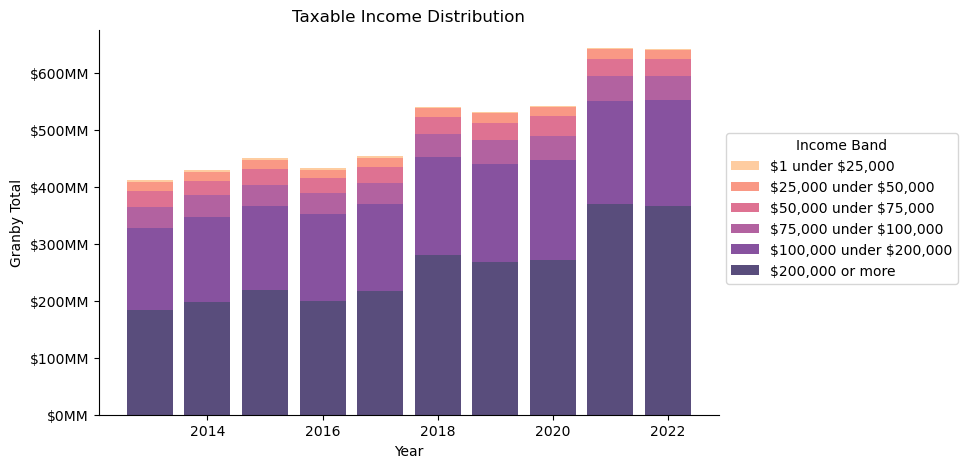

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(granby_incomes, x="Year", weights='Taxable income Amount',
             palette="magma_r", discrete=True, edgecolor=None, shrink=.8,
            hue='Income Band', multiple='stack', ax=ax)

ax.yaxis.set_major_formatter(dollar_mm_formatter)

# Add labels and title
ax.set_ylabel("Granby Total")
ax.set_title("Taxable Income Distribution")

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, .75))
sns.despine()
plt.show()

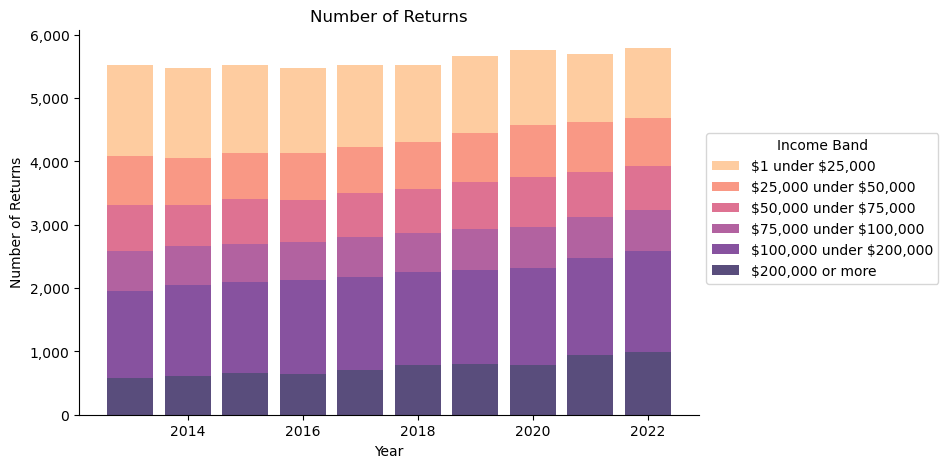

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(granby_incomes, x="Year", weights='Number of returns',
             palette="magma_r", discrete=True, edgecolor=None, shrink=.8,
            hue='Income Band', multiple='stack', ax=ax)

ax.yaxis.set_major_formatter(comma_formatter)

# Add labels and title
ax.set_ylabel("Number of Returns")
ax.set_title("Number of Returns")
sns.despine()
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, .75))
plt.show()

## Police & Public Works Spending

In [49]:
# add peer groups
district_accounts = district_accounts.merge(district_total_income, on=['Year', 'District'], how='left').query('Taxpayers.notna()')

In [50]:
district_accounts['Share of Budget'] = np.round(district_accounts['Total'] / district_accounts['Total Expenditures'], 5)
district_accounts['Share of Income'] = np.round(district_accounts['Total'] / district_accounts['Total income Amount'], 5)
district_accounts['Share of Eq GL'] = np.round(district_accounts['Total'] / district_accounts['Equalized Net Grand List'], 5)

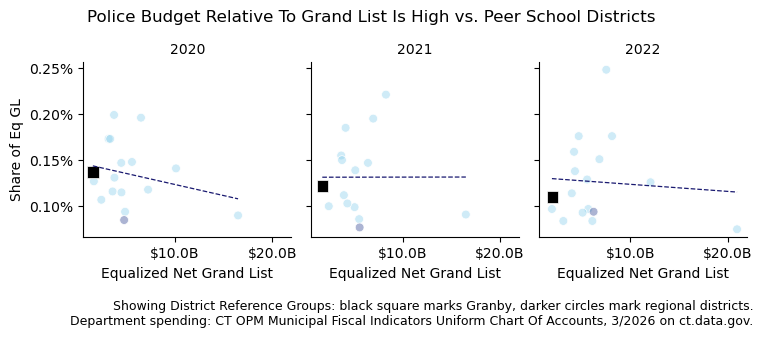

In [51]:
g = sns.relplot(data=district_accounts[district_accounts['Department Description'] == 'Police'],
                col='Year', col_wrap=3,
                y='Share of Eq GL', x='Equalized Net Grand List',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Share of Eq GL', x='Equalized Net Grand List', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(dollar_realbb_formatter)
    ax.yaxis.set_major_formatter(perc2_formatter)

g.fig.suptitle("Police Budget Relative To Grand List Is High vs. Peer School Districts")

plt.subplots_adjust(top=.82, bottom=0.28)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts.\n"
line2 = "Department spending: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts, 3/2026 on ct.data.gov."
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/district_police_gl_share.png", dpi=200, metadata=png_metadata)

plt.show()

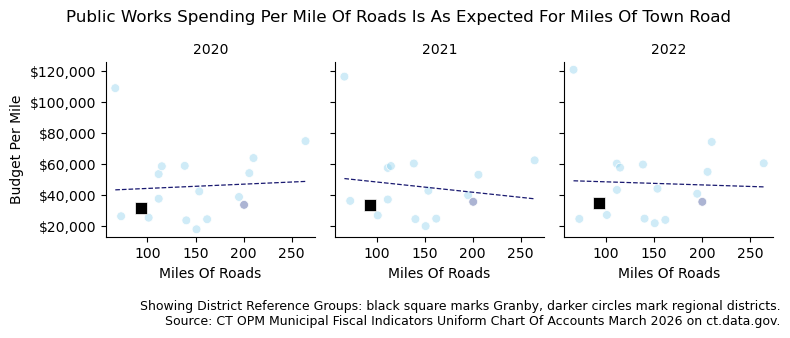

In [52]:
_df = district_accounts[district_accounts['Department Description'] == 'Public Works Total'].copy()
_df['Budget Per Mile'] = _df['Total']/_df['Town Roads']
_df['Miles Of Roads'] = _df['Town Roads']

g = sns.relplot(data=_df,
                col='Year', col_wrap=3,
                y='Budget Per Mile', x='Miles Of Roads',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Budget Per Mile', x='Miles Of Roads', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(dollari_formatter)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)

g.fig.suptitle("Public Works Spending Per Mile Of Roads Is As Expected For Miles Of Town Road")

plt.subplots_adjust(top=.82, bottom=0.28)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts.\n"
line2 = "Source: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts March 2026 on ct.data.gov."

g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/district_works_by_mile.png", dpi=200, metadata=png_metadata)

plt.show()

In [53]:
district_accounts[(district_accounts['Function Description'] == 'Public Works') & (district_accounts['District'].str.startswith('Gran'))]\
                  [['Year', 'Department Description', 'Total']]

,Year,Department Description,Total
3793,2020,Highways/Streets,0.0
3794,2020,Other Public Works,2123543.0
3795,2020,Sewer,0.0
3796,2020,Waste Management,821385.0
3822,2021,Highways/Streets,0.0
3823,2021,Other Public Works,2253658.0
3824,2021,Sewer,0.0
3825,2021,Waste Management,870595.0
3851,2022,Highways/Streets,0.0
3852,2022,Other Public Works,2314008.0


In [54]:
regional_map = {
    'Canaan': 'Regional High School District 01',
    'Cornwall': 'Regional High School District 01',
    'Kent': 'Regional High School District 01',
    'North Canaan': 'Regional High School District 01',
    'Salisbury': 'Regional High School District 01',
    'Sharon': 'Regional High School District 01',
    'Chester': 'Regional High School District 04',
    'Deep River': 'Regional High School District 04',
    'Bethany': 'Regional High School District 04',
    'Orange': 'Regional High School District 05',
    'Woodbridge': 'Regional High School District 05',
    'Essex': 'Regional High School District 05',
    'Goshen': 'Regional School District 06',
    'Morris': 'Regional School District 06',
    'Warren': 'Regional School District 06',
    'Barkhamsted': 'Regional High School District 07',
    'Colebrook': 'Regional High School District 07',
    'New Hartford': 'Regional High School District 07',
    'Norfolk': 'Regional High School District 07',
    'Andover': 'Regional High School District 08',
    'Hebron': 'Regional High School District 08',
    'Marlborough': 'Regional High School District 08',
    'Easton': 'Regional High School District 09',
    'Redding': 'Regional High School District 09',
    'Burlington': 'Regional School District 10',
    'Harwinton': 'Regional School District 10',
    'Chaplin': 'Regional High School District 11',
    'Hampton': 'Regional High School District 11',
    'Scotland': 'Regional High School District 11',
    'Bridgewater': 'Regional School District 12',
    'Roxbury': 'Regional School District 12',
    'Washington': 'Regional School District 12',
    'Durham': 'Regional School District 13',
    'Middlefield': 'Regional School District 13',
    'Bethlehem': 'Regional School District 14',
    'Woodbury': 'Regional School District 14',
    'Middlebury': 'Regional School District 15',
    'Southbury': 'Regional School District 15',
    'Beacon Falls': 'Regional School District 16',
    'Prospect': 'Regional School District 16',
    'Haddam': 'Regional School District 17',
    'Killingworth': 'Regional School District 17',
    'Lyme': 'Regional School District 18',
    'Old Lyme': 'Regional School District 18',
    'Ashford': 'Regional High School District 19',
    'Mansfield': 'Regional High School District 19',
    'Willington': 'Regional High School District 19',
}

In [55]:
# reverse map from schools to towns
dislist = list(district_total_income[district_total_income[PEERVAR] > 0].District.unique())
distowns = [x.replace(' School District', '') for x in dislist if not x.startswith('Regional')]
disreg = [x for x in dislist if x.startswith('Regional')]

regiontowns = []
for k, item in regional_map.items(): 
    regiontowns.append(k) if item in disreg else ''

townlist = distowns + regiontowns
sorted(townlist)

['Avon',
 'Brookfield',
 'Canton',
 'Cheshire',
 'Fairfield',
 'Farmington',
 'Glastonbury',
 'Granby',
 'Guilford',
 'Middlebury',
 'Monroe',
 'Oxford',
 'Rocky Hill',
 'Simsbury',
 'South Windsor',
 'Southbury',
 'Trumbull',
 'West Hartford']

In [56]:
town_accounts = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/town_chart_of_accounts.parquet')
town_accounts = town_accounts[town_accounts['Town'].isin(townlist)]
town_accounts['Granby'] = (town_accounts['Town'] == 'Granby').astype('int')
town_accounts[PEERVAR] = town_accounts['Town'].isin(regiontowns).astype('int')
town_accounts[PEERVAR] = town_accounts[PEERVAR].where(~town_accounts['Town'].isin(distowns), 3)
town_accounts[PEERVAR] = town_accounts[PEERVAR].where(town_accounts['Granby'] == 0, 2)

In [57]:
town_accounts.columns

Index(['Year', 'Entity Name', 'Function Description', 'Department Description',
       'Salaries Wages', 'Employee Benefits', 'Other', 'Total', 'Town',
       'Total Town Salaries Wages', 'Total Town Employee Benefits',
       'Total Town Other', 'Total Town Total', 'Share of Salaries Wages',
       'Share of Employee Benefits', 'Share of Other', 'Share of Total',
       'Town Area', 'State Roads', 'Town Roads', 'Population',
       'Net Equalized Grand List', 'District', 'Granby', 'finprojB'],
      dtype='object')

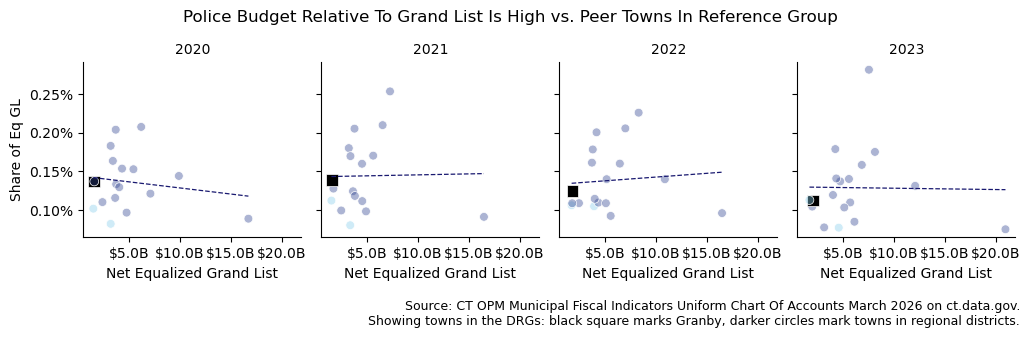

In [58]:
_df = town_accounts[town_accounts['Department Description'] == 'Police'].copy()
_df['Budget Per Person'] = _df['Total']/_df['Population']
_df['Share of Eq GL'] = _df['Total']/_df['Net Equalized Grand List']

g = sns.relplot(data=_df,
                col='Year', col_wrap=4,
                y='Share of Eq GL', x='Net Equalized Grand List',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Share of Eq GL', x='Net Equalized Grand List', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(dollar_realbb_formatter)
    ax.yaxis.set_major_formatter(perc2_formatter)

g.fig.suptitle("Police Budget Relative To Grand List Is High vs. Peer Towns In Reference Group")

plt.subplots_adjust(top=.82, bottom=0.28)
line2 = "Showing towns in the DRGs: black square marks Granby, darker circles mark towns in regional districts."
line1 = "Source: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts March 2026 on ct.data.gov.\n"
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/town_police_gl_share.png", dpi=200, metadata=png_metadata)

plt.show()

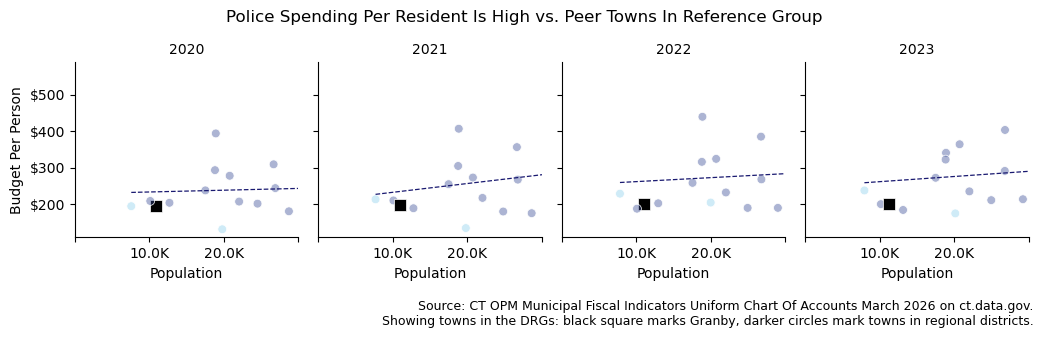

In [59]:
g = sns.relplot(data=_df,
                col='Year', col_wrap=4,
                y='Budget Per Person', x='Population',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Budget Per Person', x='Population', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(k_formatter)
    ax.yaxis.set_major_formatter(dollari_formatter)
    ax.set_xlim(0, 30000)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)

g.fig.suptitle("Police Spending Per Resident Is High vs. Peer Towns In Reference Group")

plt.subplots_adjust(top=.82, bottom=0.28)
line2 = "Showing towns in the DRGs: black square marks Granby, darker circles mark towns in regional districts."
line1 = "Source: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts March 2026 on ct.data.gov.\n"
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/town_police_per_person.png", dpi=200, metadata=png_metadata)

plt.show()

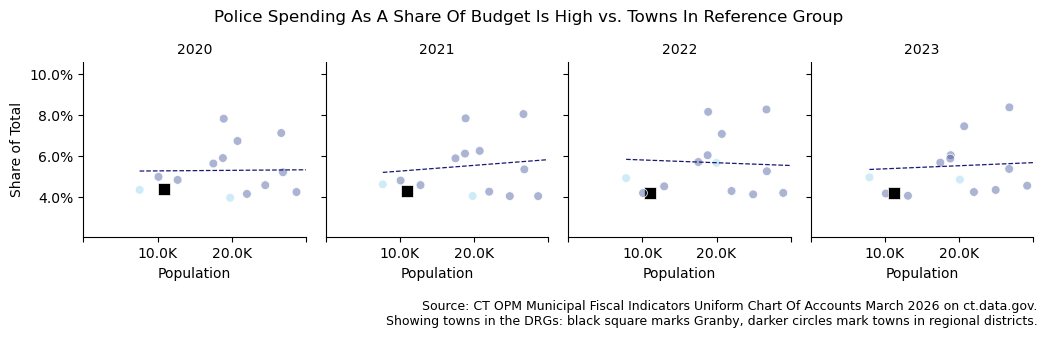

In [60]:
g = sns.relplot(data=town_accounts[town_accounts['Department Description'] == 'Police'],
                col='Year', col_wrap=4,
                y='Share of Total', x='Population',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Share of Total', x='Population', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(k_formatter)
    ax.yaxis.set_major_formatter(perc_formatter)
    ax.set_xlim(0, 30000)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)

g.fig.suptitle("Police Spending As A Share Of Budget Is High vs. Towns In Reference Group")

plt.subplots_adjust(top=.82, bottom=0.28)
line2 = "Showing towns in the DRGs: black square marks Granby, darker circles mark towns in regional districts."
line1 = "Source: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts March 2026 on ct.data.gov.\n"
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/town_police_budget_share.png", dpi=200, metadata=png_metadata)

plt.show()

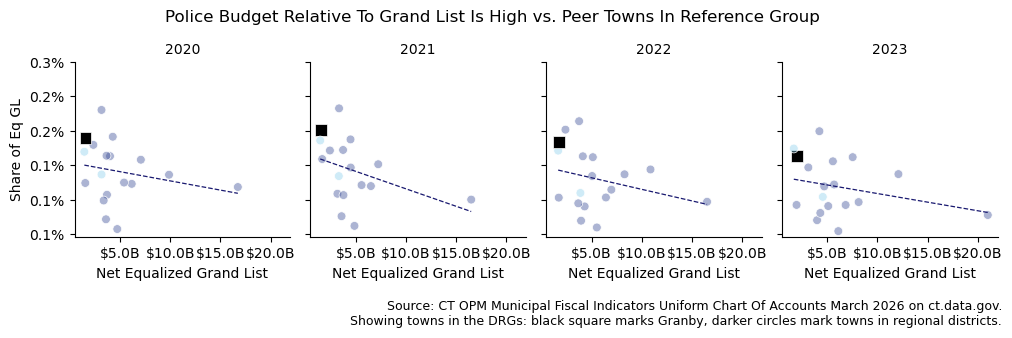

In [61]:
_df = town_accounts[town_accounts['Department Description'] == 'Public Works Total'].copy()
_df['Budget Per Person'] = _df['Total']/_df['Population']
_df['Share of Eq GL'] = _df['Total']/_df['Net Equalized Grand List']

g = sns.relplot(data=_df,
                col='Year', col_wrap=4,
                y='Share of Eq GL', x='Net Equalized Grand List',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Share of Eq GL', x='Net Equalized Grand List', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.set_ylim(top=.003)
    ax.xaxis.set_major_formatter(dollar_realbb_formatter)
    ax.yaxis.set_major_formatter(perc_formatter)

g.fig.suptitle("Police Budget Relative To Grand List Is High vs. Peer Towns In Reference Group")

plt.subplots_adjust(top=.82, bottom=0.28)
line2 = "Showing towns in the DRGs: black square marks Granby, darker circles mark towns in regional districts."
line1 = "Source: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts March 2026 on ct.data.gov.\n"
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/town_publicworks_gl_share.png", dpi=200, metadata=png_metadata)

plt.show()

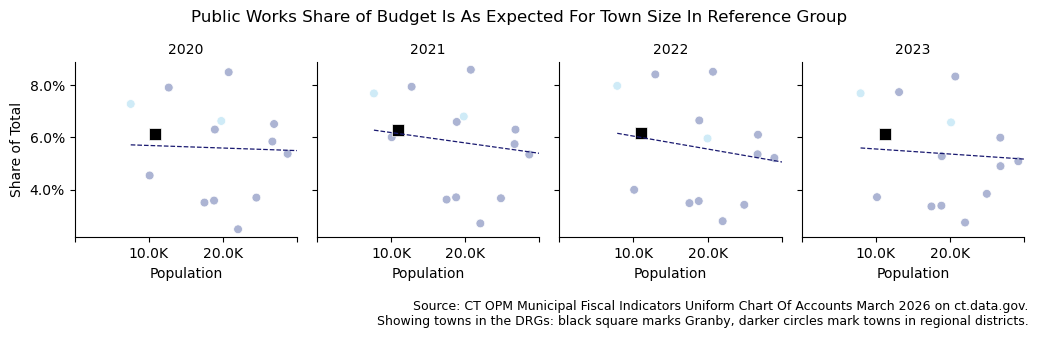

In [62]:
g = sns.relplot(data=_df,
                col='Year', col_wrap=4,
                y='Share of Total', x='Population',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Share of Total', x='Population', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(k_formatter)
    ax.yaxis.set_major_formatter(perc_formatter)
    ax.set_xlim(0, 30000)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)


g.fig.suptitle("Public Works Share of Budget Is As Expected For Town Size In Reference Group")

plt.subplots_adjust(top=.82, bottom=0.28)
line2 = "Showing towns in the DRGs: black square marks Granby, darker circles mark towns in regional districts."
line1 = "Source: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts March 2026 on ct.data.gov.\n"
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/town_publicworks_budget_share.png", dpi=200, metadata=png_metadata)

plt.show()

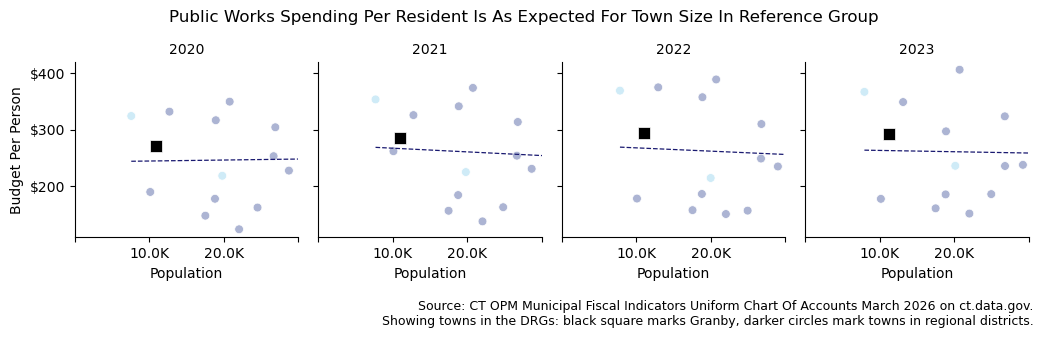

In [63]:
g = sns.relplot(data=_df,
                col='Year', col_wrap=4,
                y='Budget Per Person', x='Population',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Budget Per Person', x='Population', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(k_formatter)
    ax.yaxis.set_major_formatter(dollari_formatter)
    ax.set_xlim(0, 30000)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)

g.fig.suptitle("Public Works Spending Per Resident Is As Expected For Town Size In Reference Group")

plt.subplots_adjust(top=.82, bottom=0.28)
line2 = "Showing towns in the DRGs: black square marks Granby, darker circles mark towns in regional districts."
line1 = "Source: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts March 2026 on ct.data.gov.\n"

g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/town_publicworks_per_person.png", dpi=200, metadata=png_metadata)

plt.show()

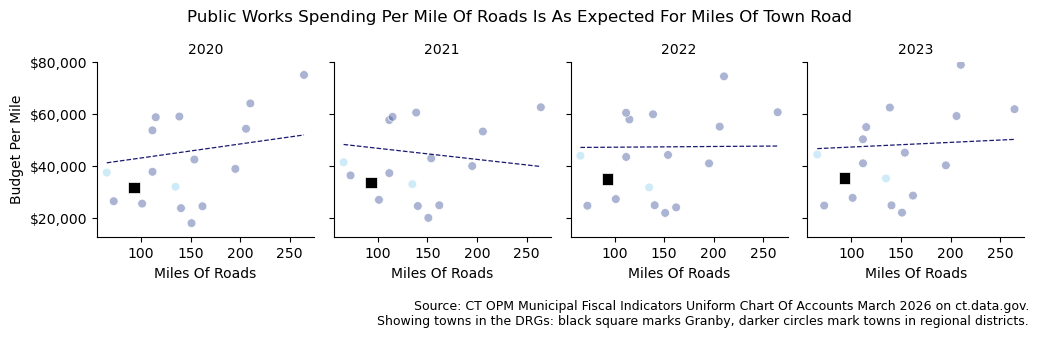

In [64]:
_df = town_accounts[town_accounts['Department Description'] == 'Public Works Total'].copy()
_df['Budget Per Mile'] = _df['Total']/_df['Town Roads']
_df['Miles Of Roads'] = _df['Town Roads']

g = sns.relplot(data=_df,
                col='Year', col_wrap=4,
                y='Budget Per Mile', x='Miles Of Roads',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Budget Per Mile', x='Miles Of Roads', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.set_ylim(top=80000)
    ax.yaxis.set_major_formatter(dollari_formatter)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)

g.fig.suptitle("Public Works Spending Per Mile Of Roads Is As Expected For Miles Of Town Road")

plt.subplots_adjust(top=.82, bottom=0.28)
line2 = "Showing towns in the DRGs: black square marks Granby, darker circles mark towns in regional districts."
line1 = "Source: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts March 2026 on ct.data.gov.\n"

g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/town_publicworks_per_mile.png", dpi=200, metadata=png_metadata)
plt.show()